In [1]:
import pandas as pd
import numpy as np
import duckdb
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import matplotlib.colors as mcolors
import seaborn as sns
from datetime import datetime, timedelta
import json
import os
import re
import sys
from typing import List, Tuple, Optional, Dict, Literal
from glob import glob
from IPython.display import display, clear_output
import calendar
import math
import random
import july
from plotly_calheatmap import (
    calendar_calheatmap, calheatmap,
    month_calheatmap, hourly_calheatmap
)
from custom_calendar_visuals import calendar_plot_binary, calendar_plot_categorical
from scipy.stats import pearsonr, linregress
from statsmodels.tsa.stattools import acf
from statsmodels.tsa.seasonal import STL
from scipy.signal import find_peaks
from scipy.signal import detrend
from scipy.fft import fft, fftfreq
from scipy.stats import shapiro, ks_2samp
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [2]:
pd.options.display.max_columns = None

In [3]:
con = duckdb.connect(
    database = "../data/MIG_Cement_Records.db",
    read_only = True
)

In [4]:
query = """

    SELECT
        *
    FROM
        Operations
    ORDER BY
        date::DATE ASC,
        site_id ASC
    LIMIT 5;
"""

con.execute(query).df()

,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
0,2022-01-01,SITE_001,CEM_II,43.18,34.54,52.56,45.83,63.85,3.40,-3.10,448
1,2022-01-01,SITE_002,CEM_I,15.70,15.70,28.46,12.12,24.87,3.31,4.86,288
2,2022-01-01,SITE_003,CEM_II,57.45,57.45,68.13,31.51,42.19,2.85,21.19,314
3,2022-01-01,SITE_004,CEM_I,6.75,6.75,24.47,43.42,61.14,0.02,9.48,472
4,2022-01-01,SITE_005,CEM_II,42.42,0.00,79.21,46.97,126.18,29.77,23.52,230


In [5]:
OPERATION_START_DATE = con.execute("SELECT MIN(date) FROM Operations").fetchone()[0]
OPERATION_END_DATE = con.execute("SELECT MAX(date) FROM Operations").fetchone()[0]

In [6]:
print(f"OPERATION_START_DATE: {OPERATION_START_DATE}")
print(f"OPERATION_END_DATE: {OPERATION_END_DATE}")

OPERATION_START_DATE: 2022-01-01
OPERATION_END_DATE: 2024-12-31


In [7]:
operations_columns = con.execute(" SELECT * FROM Operations LIMIT 1 ").df().columns.tolist()
operations_columns

['date',
 'site_id',
 'cement_type',
 'planned_pour_tonnes',
 'consumed_tonnes',
 'opening_inventory_tonnes',
 'deliveries_tonnes',
 'closing_inventory_tonnes',
 'rain_mm',
 'avg_temp_c',
 'silo_capacity']

THREE YEARS (1096 days) OF SITE ACTIVITIES

In [8]:
query = " SELECT MAX(date::DATE) - MIN(date::DATE) FROM Operations; "

con.execute(query).fetchone()

(1095,)

ALL SITES HAVE A RECORD FOR EACH DAY

In [9]:
query = """

    SELECT
        site_id,
        COUNT(DISTINCT(date)) as total_recorded_days
    FROM
        Operations
    GROUP BY
        site_id;
"""

df = con.execute(query).df()
df.total_recorded_days.unique()

array([1096])

ONE CEMENT ACTIVITY PER DAY

In [10]:
query = """

    PIVOT
        Operations
    ON
        site_id
    USING
        COUNT(*)
    GROUP BY
        date;
"""

pivot_df = con.execute(query).df()
pivot_df.set_index("date", inplace = True)
pivot_df.head()

,SITE_001,SITE_002,SITE_003,SITE_004,SITE_005,SITE_006,SITE_007,SITE_008,SITE_009,SITE_010,SITE_011,SITE_012,SITE_013,SITE_014,SITE_015,SITE_016,SITE_017,SITE_018,SITE_019,SITE_020,SITE_021,SITE_022,SITE_023,SITE_024,SITE_025,SITE_026,SITE_027,SITE_028,SITE_029,SITE_030
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2023-06-18,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2023-08-07,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2023-08-31,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2024-04-01,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
2024-04-06,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


In [11]:
np.unique(pivot_df.values.flatten())

array([1])

OVER 2.9K RECORDS WITH NO PLANNED ACTIVITY

In [12]:
query = " SELECT COUNT(1) FROM Operations WHERE planned_pour_tonnes == 0; "

con.execute(query).fetchone()

(2993,)

ALL 2.9K NO PLANNED ACTIVITY RECORDS ARE DISTRIBUTED OVER 1K DAYS

In [13]:
query = " SELECT COUNT(DISTINCT(date)) FROM Operations WHERE planned_pour_tonnes == 0; "

con.execute(query).fetchone()

(1039,)

OVER 4K RECORDS WITH NO CEMENT CONSUMPTION ACTIVITY

In [14]:
query = " SELECT COUNT(1) FROM Operations WHERE consumed_tonnes == 0; "

con.execute(query).fetchone()

(4003,)

ALL 4K NO CEMENT CONSUMPTION ACTIVITY RECORDS ARE DISTRIBUTED OVER 1K DAYS

In [15]:
query = " SELECT COUNT(DISTINCT(date)) FROM Operations WHERE consumed_tonnes == 0; "

con.execute(query).fetchone()

(1079,)

NO CONSUMPTION ACTIVITY WHEN THERE IS NO PLANNED ACTIVITY (SANITY CHECKED)

In [16]:
query = """ SELECT
                COUNT(1)
            FROM
                Operations
            WHERE
                planned_pour_tonnes == 0
                AND
                consumed_tonnes > 0;
        """

con.execute(query).fetchone()

(0,)

OVER 1K RECORDS OF NO CONSUMPTION ACTIVITY WITH SCHEDULED PLANNED ACTIVITY

In [17]:
query = """ SELECT
                COUNT(1)
            FROM
                Operations
            WHERE
                planned_pour_tonnes > 0
                AND
                consumed_tonnes == 0;
        """

con.execute(query).fetchone()

(1010,)

179 INSTANCES WITHOUT ANY ACTIVITY ON SITE
(NO CONSUMPTION AND NO DELIVERY)

In [18]:
query = """

    SELECT
        COUNT(1)
    FROM
        Operations
    WHERE
        planned_pour_tonnes + consumed_tonnes + deliveries_tonnes == 0;
"""

con.execute(query).fetchone()

(179,)

In [19]:
query = """

    SELECT
        *
    FROM
        Operations
    WHERE
        planned_pour_tonnes + consumed_tonnes + deliveries_tonnes == 0
    LIMIT 5;
"""

con.execute(query).df()

,date,site_id,cement_type,planned_pour_tonnes,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes,rain_mm,avg_temp_c,silo_capacity
0,2022-02-05,SITE_006,CEM_III,0.0,0.0,58.27,0.0,58.27,5.40,9.77,443
1,2022-02-06,SITE_006,CEM_II,0.0,0.0,58.27,0.0,58.27,6.78,14.85,443
2,2022-02-24,SITE_006,CEM_II,0.0,0.0,120.71,0.0,120.71,4.03,13.30,443
3,2022-03-24,SITE_006,CEM_II,0.0,0.0,218.73,0.0,218.73,2.14,16.29,443
4,2022-06-04,SITE_006,CEM_II,0.0,0.0,38.47,0.0,38.47,1.06,14.90,443


THIS HAPPENED ACROSS 7 SITES

In [20]:
query = """

    SELECT
        COUNT(DISTINCT(site_id))
    FROM
        Operations
    WHERE
        planned_pour_tonnes + consumed_tonnes + deliveries_tonnes == 0;
"""

con.execute(query).fetchone()

(7,)

In [21]:
query = """

    SELECT
        site_id,
        COUNT(1) as frequency
    FROM
        Operations
    WHERE
        planned_pour_tonnes + consumed_tonnes + deliveries_tonnes == 0
    GROUP BY
        site_id
    ORDER BY
        frequency DESC;
"""

con.execute(query).df()

,site_id,frequency
0,SITE_016,31
1,SITE_028,30
2,SITE_006,28
3,SITE_026,26
4,SITE_024,25
5,SITE_014,22
6,SITE_013,17


In [22]:
query = """

    SELECT
        site_id,
        COUNT(1) as frequency
    FROM
        Operations
    WHERE
        planned_pour_tonnes > 0
        AND
        consumed_tonnes == 0
    GROUP BY
        site_id
    ORDER BY
        frequency DESC;
"""

con.execute(query).df()

,site_id,frequency
0,SITE_003,63
1,SITE_011,57
2,SITE_007,57
3,SITE_021,55
4,SITE_025,54
5,SITE_001,53
6,SITE_017,53
7,SITE_030,51
8,SITE_010,50
9,SITE_008,49


In [23]:
def annotate_activity_days(site_id: str, year: int) -> None:

    query = """ SELECT
                    date,
                    CASE
                        WHEN planned_pour_tonnes > 0 and consumed_tonnes == 0 THEN 1
                        WHEN planned_pour_tonnes > 0 AND consumed_tonnes > 0 THEN -1
                        WHEN planned_pour_tonnes == 0 AND consumed_tonnes == 0 THEN 0
                    END AS active
                FROM
                    Operations
                WHERE
                    site_id == ?
                    AND
                    YEAR(date::DATE) == ?
                ORDER BY
                    date::DATE ASC;  
            """

    df = con.execute(query, [site_id, year]).df()

    cmap = [
        "#66BB6A",
        "#EF5350",
        "#E0E0E0",
    ]

    category_colors = {
        1: "#EF5350",
        0: "#E0E0E0",
        -1: "#66BB6A"
    }

    calendar_plot_categorical(
        df.date,
        df.active,
        cmap = cmap,
        category_colors = category_colors
    )

- RED CELLS: PLANNED ACTIVITY BUT NO CONSUMPTION (HEAVY RAIN OR EMPTY INVENTORY)
- GREEN CELLS: PLANNED ACTIVITY AND CONSUMPTION
- GREY CELLS: NO PLANNED ACTIVITY, NO CONSUMPTION

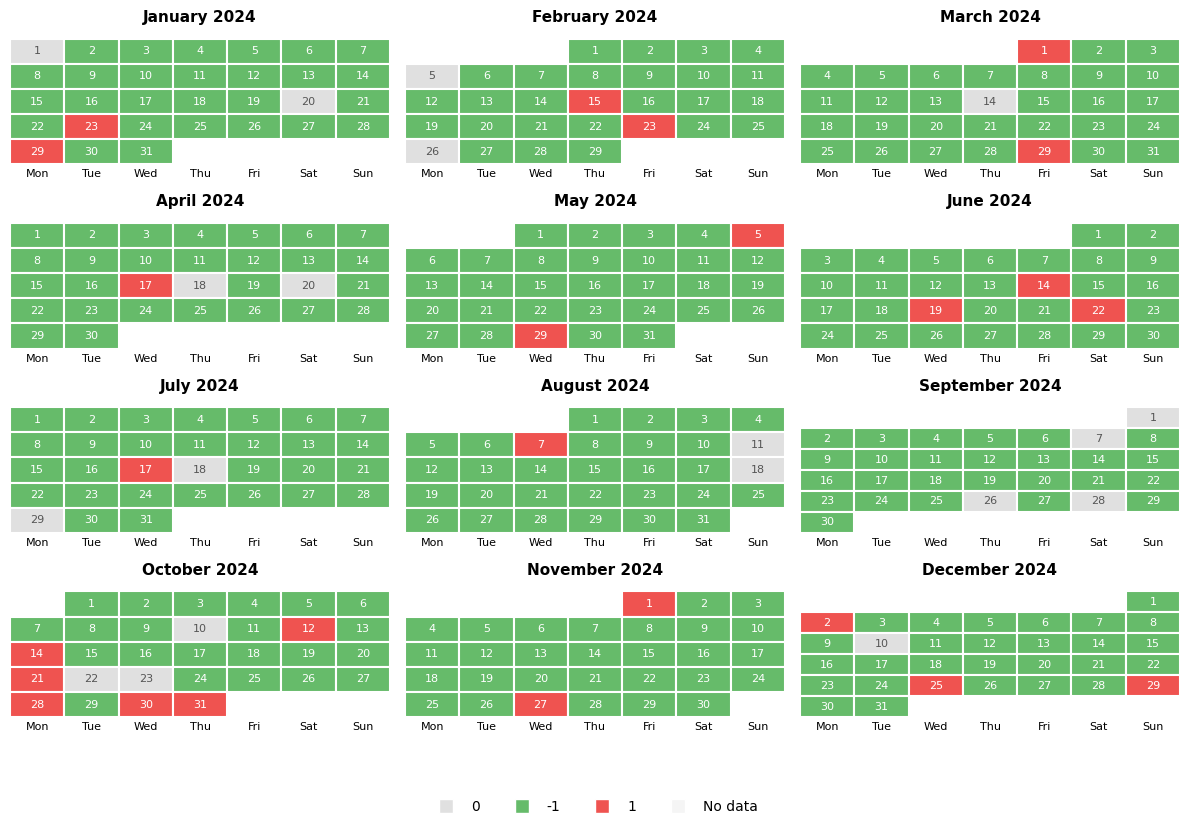

In [24]:
annotate_activity_days("SITE_003", 2024)

ON PLANNED POUR ACTIVITY BUT NO CONSUMPTION (1010 Instances)
- There was enough cement in the inventory to use (262 Instances)
- There was not enough cement for the planned pour (Including potential delivery) (531 Instances)
- There was not enough cement in inventory but delivery was made to cover (Potentially late delivery) (217 Instances).

In [25]:
query = """ SELECT
                COUNT(1)
            FROM
                Operations
            WHERE
                (planned_pour_tonnes > 0 AND consumed_tonnes == 0)
                AND
                (opening_inventory_tonnes > planned_pour_tonnes);
        """

con.execute(query).fetchone()

(262,)

In [26]:
query = """ SELECT
                COUNT(1)
            FROM
                Operations
            WHERE
                (planned_pour_tonnes > 0 AND consumed_tonnes == 0)
                AND
                (closing_inventory_tonnes < planned_pour_tonnes);
        """

con.execute(query).fetchone()

(531,)

In [27]:
query = """ SELECT
                COUNT(1)
            FROM
                Operations
            WHERE
                (planned_pour_tonnes > 0 AND consumed_tonnes == 0)
                AND
                (opening_inventory_tonnes < planned_pour_tonnes)
                AND
                (closing_inventory_tonnes >= planned_pour_tonnes);
        """

con.execute(query).fetchone()

(217,)

In [28]:
data = con.execute(" SELECT site_id, rain_mm FROM Operations; ").df()

In [29]:
for site in data.site_id.unique():
    stat, p_value = shapiro(data.loc[data.site_id == site, "rain_mm"].values)
    if p_value > 0.05:
        print(f"Distribution of Rain at {site} is normal")

In [30]:
for site in data.site_id.unique():
    difference, p_value = ks_2samp(
        data.rain_mm.values,
        data.loc[data.site_id == site, "rain_mm"].values
    )
    if p_value < 0.05:
        print(f"Distribution of Rain at {site} is significantly different from general population: difference ({difference.round(3)}), p_value ({p_value.round(3)})")

Distribution of Rain at SITE_014 is significantly different from general population: difference (0.044), p_value (0.03)
Distribution of Rain at SITE_024 is significantly different from general population: difference (0.053), p_value (0.005)
Distribution of Rain at SITE_029 is significantly different from general population: difference (0.054), p_value (0.004)


In [31]:
def visualize_difference(site_id: str, data: pd.DataFrame = data) -> None:

    sample_distribution = data.loc[data.site_id == site_id, "rain_mm"].values
    population_distribution = data.rain_mm.values

    concat = np.concatenate([sample_distribution, population_distribution])
    uniques = np.unique(concat)
    uniques.sort()

    sample_cdf = np.array([sample_distribution[sample_distribution <= v].size / sample_distribution.size for v in uniques])
    population_cdf = np.array([population_distribution[population_distribution <= v].size / population_distribution.size for v in uniques])

    difference, p_value = ks_2samp(sample_distribution, population_distribution)

    fig, ax = plt.subplots(1, 3, figsize = (12, 10))

    sns.histplot(population_distribution, kde = True, ax = ax[0])
    sns.lineplot(x = uniques, y = population_cdf, color = "blue", ax = ax[1])
    sns.lineplot(x = uniques, y = sample_cdf, color = "red", ax = ax[1])
    sns.histplot(sample_distribution, kde = True, ax = ax[2])

    ax[0].set_title("Rain Distribution across Sites")
    ax[1].set_title(f"Rain Distribution Difference: {site_id} vs Other Sites")
    ax[2].set_title(f"Rain Distribution at {site_id}")

    plt.suptitle(f"Difference: {difference.round(3)}, P-Value: {p_value.round(3)}")

    plt.tight_layout()
    plt.show()

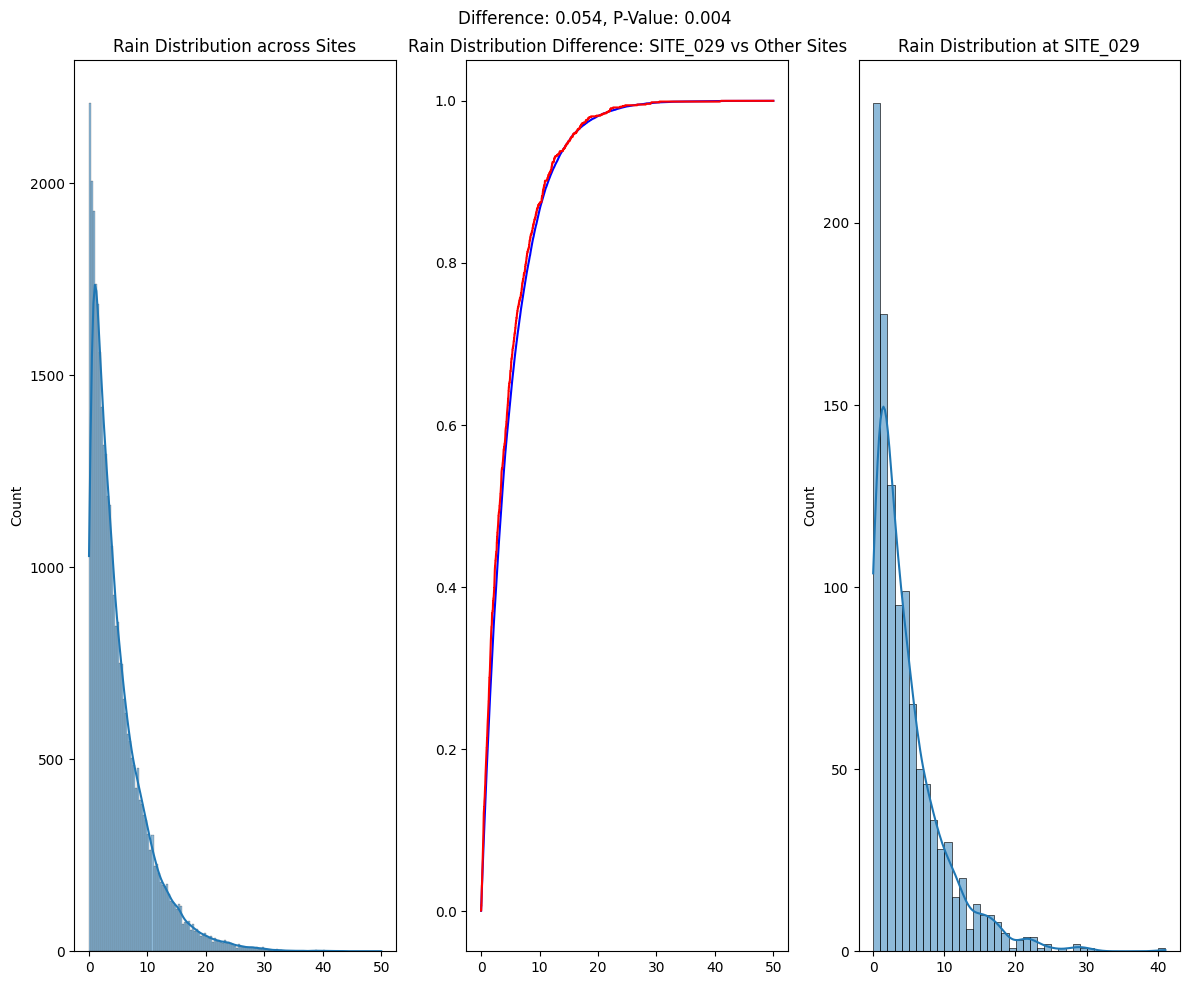

In [32]:
visualize_difference("SITE_029")

> NOT REALLY MUCH DIFFERENCE 

A CASE CAN BE MADE THAT HEAVY STORM MIGHT HAVE PREVENTED ACTIVITY WHEN IN FACT THERE WAS CEMENT AVAILABLE IN THE INVENTORY TO WORK WITH

In [33]:
query = """ SELECT
                rain_mm
            FROM
                Operations
            WHERE
                (planned_pour_tonnes > 0 AND consumed_tonnes == 0)
                AND
                (opening_inventory_tonnes > planned_pour_tonnes);
        """

idle_rain_data = con.execute(query).df().values.ravel()
active_rain_data = con.execute(" SELECT rain_mm FROM Operations WHERE consumed_tonnes > 0 ").df().values.ravel()

concat = np.concatenate([idle_rain_data, active_rain_data])
uniques = np.unique(concat)
uniques.sort()

idle_cdf = np.array([idle_rain_data[idle_rain_data <= v].size / idle_rain_data.size for v in uniques])
active_cdf = np.array([active_rain_data[active_rain_data <= v].size / active_rain_data.size for v in uniques])


difference, p_value = ks_2samp(idle_rain_data, active_rain_data)

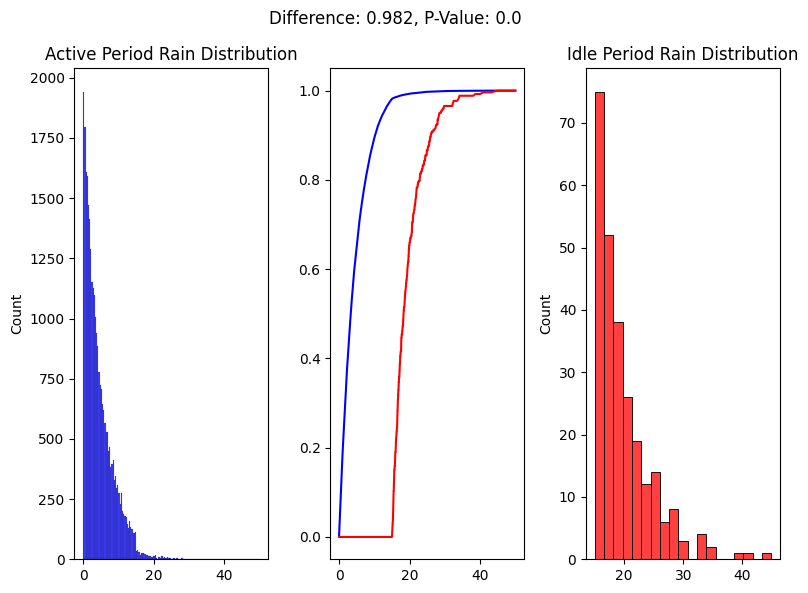

In [34]:
fig, ax = plt.subplots(1, 3, figsize = (8, 6))

sns.histplot(active_rain_data, color = "blue", ax = ax[0])
sns.lineplot(x = uniques, y = active_cdf, color = "blue", ax = ax[1])
sns.lineplot(x = uniques, y = idle_cdf, color = "red", ax = ax[1])
sns.histplot(idle_rain_data, color = "red", ax = ax[2])


ax[0].set_title("Active Period Rain Distribution")
ax[2].set_title("Idle Period Rain Distribution")
plt.suptitle(f"Difference: {difference.round(3)}, P-Value: {p_value.round(3)}")

plt.tight_layout()
plt.show()

In [35]:
data = con.execute(" SELECT site_id, avg_temp_c FROM Operations; ").df()

In [36]:
for site in data.site_id.unique():
    stat, p_value = shapiro(data.loc[data.site_id == site, "avg_temp_c"].values)
    if p_value > 0.05:
        print(f"Temperature Distribution at {site} is normal")

In [37]:
for site in data.site_id.unique():
    difference, p_value = ks_2samp(
        data.avg_temp_c.values,
        data.loc[data.site_id == site, "avg_temp_c"].values
    )
    if p_value < 0.05:
        print(f"Distribution of Temperature at {site} is significantly different from general population: difference ({difference.round(3)}), p_value ({p_value.round(3)})")

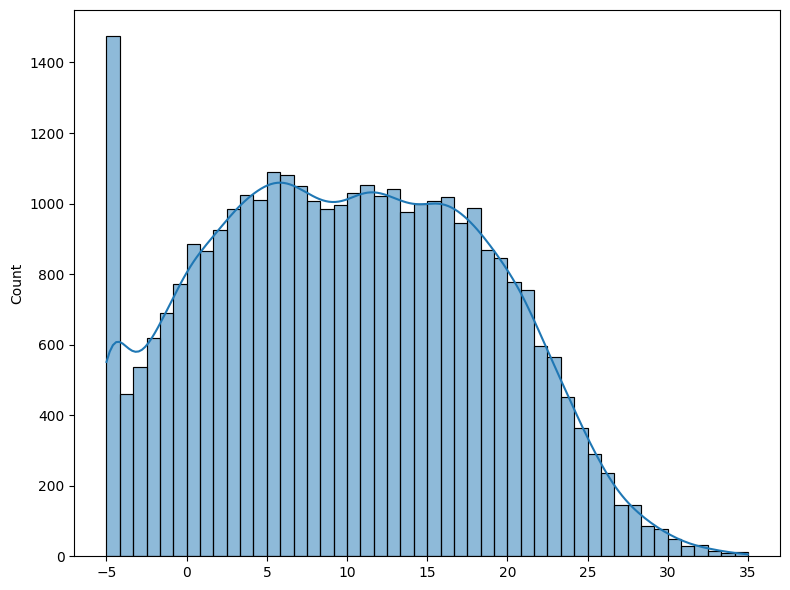

In [38]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.histplot(data.avg_temp_c.values, kde = True, ax = ax)

plt.tight_layout()
plt.show()

HEAVY STORM INFLUENCE THE DIFFERENCE BETWEEN PLANNED TONNES AND CONSUMED TONNES

In [39]:
query = """
    SELECT
        rain_mm,
        avg_temp_c,
        planned_pour_tonnes,
        consumed_tonnes,
        opening_inventory_tonnes,
        (planned_pour_tonnes - consumed_tonnes) delta
    FROM
        Operations;
"""

rain_effect_df = con.execute(query).df()

In [40]:
rain_effect_df["temp_category"] = pd.cut(
    rain_effect_df.avg_temp_c,
    bins = [-np.inf, 0, 10, 20, 30, np.inf],
    labels = ["sub_zero", "chilling", "cool", "ambient", "hot"]
)

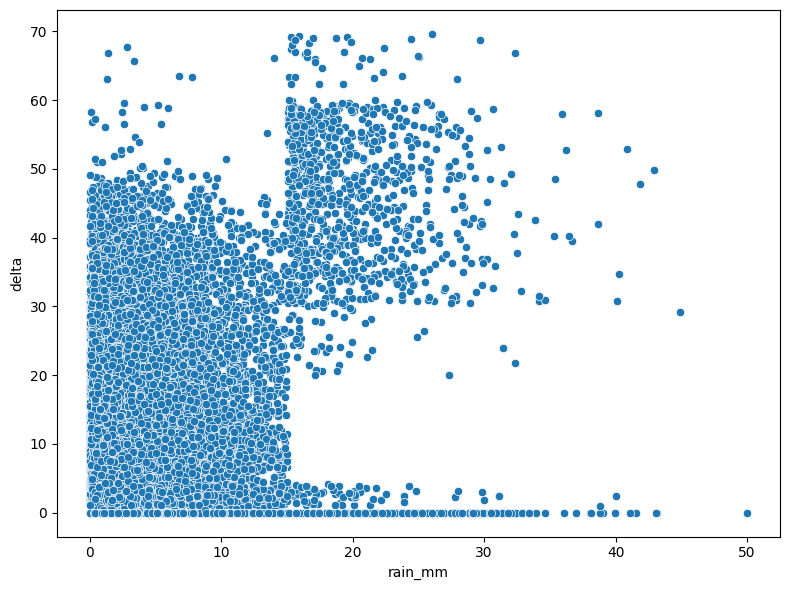

In [41]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.scatterplot(data = rain_effect_df, x = "rain_mm", y = "delta", ax = ax)

plt.tight_layout()
plt.show()

IT ISN'T THAT STORM EXPLAIN VARIANCE IN DIFFERENCE BETWEEN PLANNED AND CONSUMED CEMENT, IT IS JUST THAT; AT ABOVE 15MM, ACTIVITIES ARE MOST LIKELY HALTED.

In [42]:
rain_effect_df.loc[
    (rain_effect_df.delta > 25) &
    (rain_effect_df.rain_mm > 15),
    "consumed_tonnes"
].value_counts()

consumed_tonnes
0.0    939
Name: count, dtype: int64

WHAT IS THE PROBABILITY THAT THERE WOULD BE NO CEMENT CONSUMPTION ON A PLANNED POUR GIVEN THAT THERE IS A HEAVY STORM (RAIN >= 15MM)

In [43]:
probability_heavy_storm = rain_effect_df.loc[(rain_effect_df.rain_mm >= 15) & (rain_effect_df.planned_pour_tonnes > 0)].shape[0] / rain_effect_df.loc[rain_effect_df.planned_pour_tonnes > 0].shape[0]
round(probability_heavy_storm, 4)

0.0498

In [44]:
no_cement_consumption_heavy_storm = rain_effect_df.loc[
    (rain_effect_df.rain_mm >= 15) &
    (rain_effect_df.consumed_tonnes == 0) &
    (rain_effect_df.planned_pour_tonnes > 0)
].shape[0]

heavy_storm = rain_effect_df.loc[
    (rain_effect_df.rain_mm >= 15) &
    (rain_effect_df.planned_pour_tonnes > 0)
].shape[0]

probability_no_cement_consumption_during_heavy_storm = no_cement_consumption_heavy_storm / heavy_storm

round(probability_no_cement_consumption_during_heavy_storm, 3)

0.648

In [45]:
probability_no_cement_consumption = rain_effect_df.loc[
    (rain_effect_df.consumed_tonnes == 0) &
    (rain_effect_df.planned_pour_tonnes > 0)
].shape[0] / rain_effect_df.loc[rain_effect_df.planned_pour_tonnes > 0].shape[0]

round(probability_no_cement_consumption, 3)

0.034

In [46]:
probability_no_cement_consumption_given_heavy_storm = (probability_no_cement_consumption_during_heavy_storm * probability_heavy_storm) / probability_no_cement_consumption

round(probability_no_cement_consumption_given_heavy_storm, 3)

0.954

> There is 95% chance that consumption would be halted on a planned pour during heavy storm (>= 15mm)

OR IT COULD BE THAT THERE ARE NO AVAILABLE INVENTORY DURING THE HEAVY STORM

In [47]:
heavy_rain = rain_effect_df.loc[
    (rain_effect_df.planned_pour_tonnes > 0) &
    (rain_effect_df.rain_mm >= 15)
].shape[0]

no_inventory_heavy_rain = rain_effect_df.loc[
    (rain_effect_df.planned_pour_tonnes > 0) &
    (rain_effect_df.rain_mm >= 15) &
    (rain_effect_df.opening_inventory_tonnes == 0)
].shape[0]

prob_no_inventory_during_heavy_rain = no_inventory_heavy_rain / heavy_rain

round(prob_no_inventory_during_heavy_rain, 3)

0.235

> There is little overlap (< 25%) of no inventory during heavy rain

TEMPERATURE DOES NOT EXPLAIN THE VARIANCE IN THE DIFFERENCE BETWEEN PLANNED AND CONNSUMED TONNES

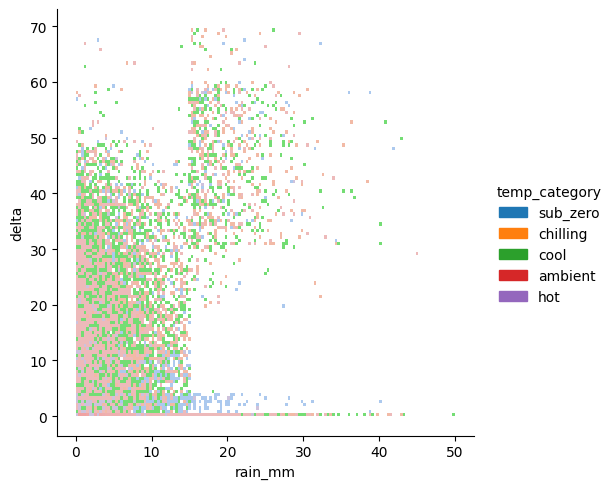

In [48]:
sns.displot(data = rain_effect_df, x = "rain_mm", y = "delta", hue = "temp_category", ax = ax)

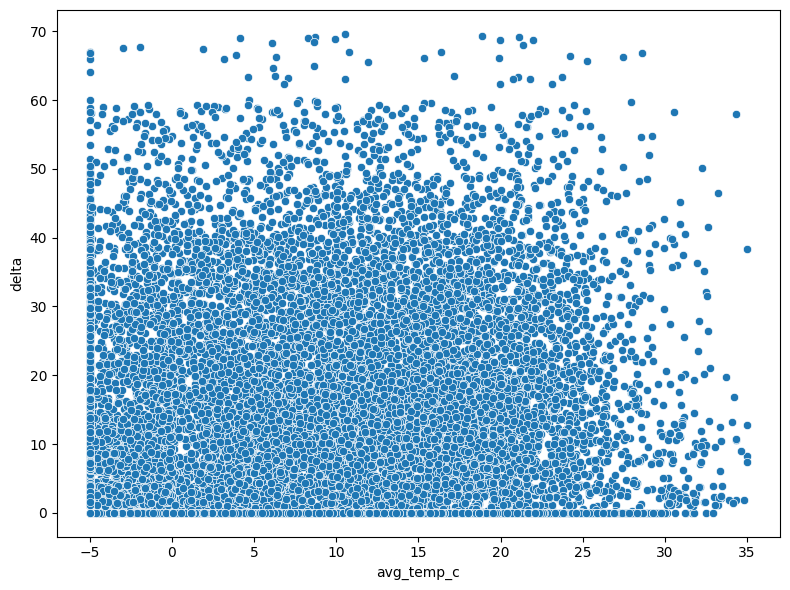

In [49]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.scatterplot(data = rain_effect_df, x = "avg_temp_c", y = "delta", ax = ax)

plt.tight_layout()
plt.show()

In [50]:
query = """

    SELECT
        date::DATE as date,
        site_id,
        cement_type,
        rain_mm,
        avg_temp_c,
        planned_pour_tonnes,
        consumed_tonnes
    FROM
        Operations
    ORDER BY
        date::DATE ASC
"""

data = con.execute(query).df()

In [51]:
data.head()

,date,site_id,cement_type,rain_mm,avg_temp_c,planned_pour_tonnes,consumed_tonnes
0,2022-01-01,SITE_001,CEM_II,3.40,-3.10,43.18,34.54
1,2022-01-01,SITE_002,CEM_I,3.31,4.86,15.70,15.70
2,2022-01-01,SITE_003,CEM_II,2.85,21.19,57.45,57.45
3,2022-01-01,SITE_004,CEM_I,0.02,9.48,6.75,6.75
4,2022-01-01,SITE_005,CEM_II,29.77,23.52,42.42,0.00


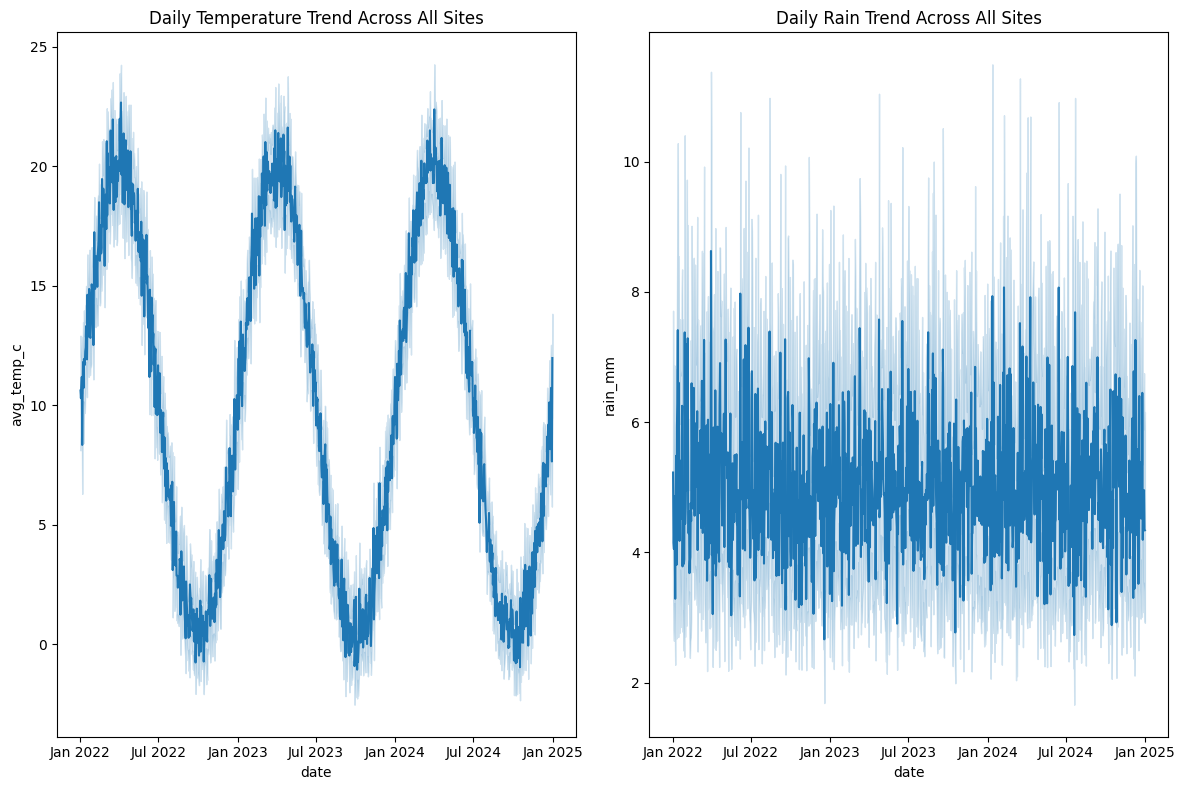

In [52]:
fig, ax = plt.subplots(1, 2, figsize = (12, 8))

sns.lineplot(data = data, x = "date", y = "avg_temp_c", ax = ax[0])
sns.lineplot(data = data, x = "date", y = "rain_mm", ax = ax[1])

ax[0].xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=5))
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax[1].xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=5))
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

ax[0].set_title("Daily Temperature Trend Across All Sites")
ax[1].set_title("Daily Rain Trend Across All Sites")

plt.tight_layout()
plt.show()

In [53]:
def correlation(site_a: str, site_b: str,
                variable: Literal["rain_mm", "avg_temp_c"] = "rain_mm",
                data: pd.DataFrame = data) -> Tuple[float, float]:

    series_a = data.loc[data.site_id == site_a, variable]
    series_b = data.loc[data.site_id == site_b, variable]

    coef, p_value = pearsonr(series_a, series_b)
    return coef.round(3), p_value.round(3)

RAIN PATTERN IS QUITE UNIQUE FOR EACH SITE BUT TEMPERATURE PATTERN IS HIGHLY CORRELATED ACROSS SITES

In [54]:
sites = data.site_id.unique().tolist()
sites.sort()

In [55]:
site_rain_pattern_correlation = []
site_rain_pattern_p_value = []
for site_a in sites:
    temp_correlation = []
    temp_pvlaue = []
    for site_b in sites:
        coef, p_value = correlation(site_a, site_b)

        temp_correlation.append(coef)
        temp_pvlaue.append(p_value)
    site_rain_pattern_correlation.append(temp_correlation)
    site_rain_pattern_p_value.append(temp_pvlaue)

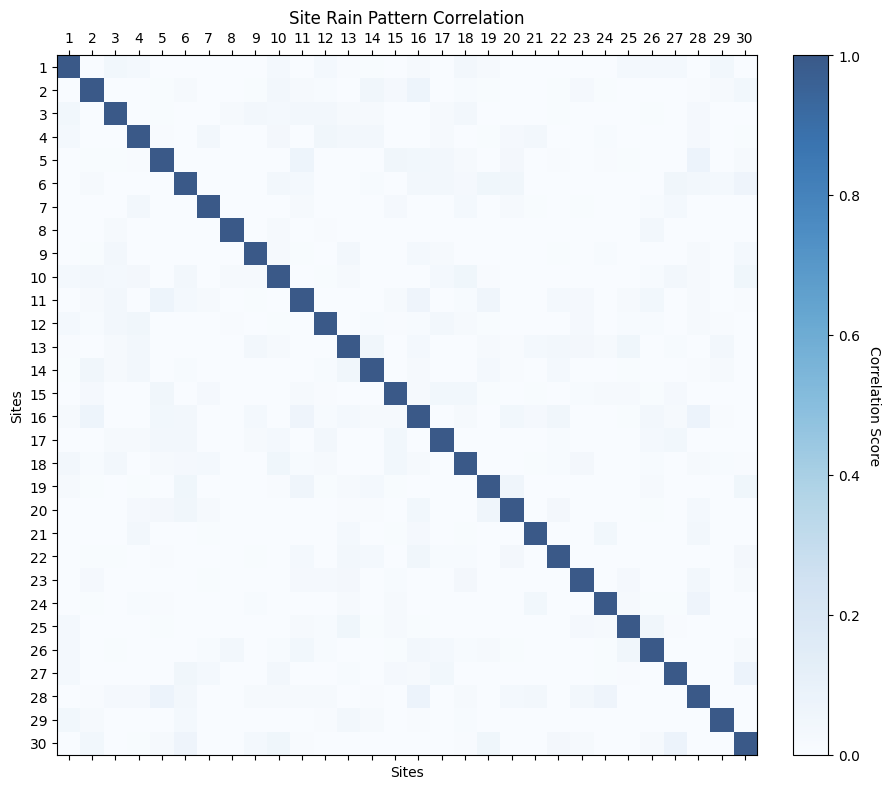

In [56]:
matrix = np.array(site_rain_pattern_correlation)
fig, ax = plt.subplots(figsize = (10, 8))

norm = mcolors.Normalize(vmin = 0, vmax = 1)

im = ax.matshow(matrix, cmap = plt.cm.Blues, norm = norm, alpha = 0.8)

# for i in range(matrix.shape[0]):
#     for j in range(matrix.shape[1]):
#         ax.text(x = j, y = i, s = matrix[i, j], va = "center", ha = "center", size = "small")

ax.set_xticks(range(matrix.shape[1]))
ax.set_yticks(range(matrix.shape[0]))

ax.set_xticklabels(range(1, 31))
ax.set_yticklabels(range(1, 31))

ax.set_xlabel("Sites", fontsize = 10)
ax.set_ylabel("Sites", fontsize = 10)

ax.set_title("Site Rain Pattern Correlation")

cbar = fig.colorbar(im, ax = ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlation Score", rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

In [57]:
site_temp_pattern_correlation = []
site_temp_pattern_p_value = []
for site_a in sites:
    temp_correlation = []
    temp_pvlaue = []
    for site_b in sites:
        coef, p_value = correlation(site_a, site_b, variable = "avg_temp_c")

        temp_correlation.append(coef)
        temp_pvlaue.append(p_value)
    site_temp_pattern_correlation.append(temp_correlation)
    site_temp_pattern_p_value.append(temp_pvlaue)

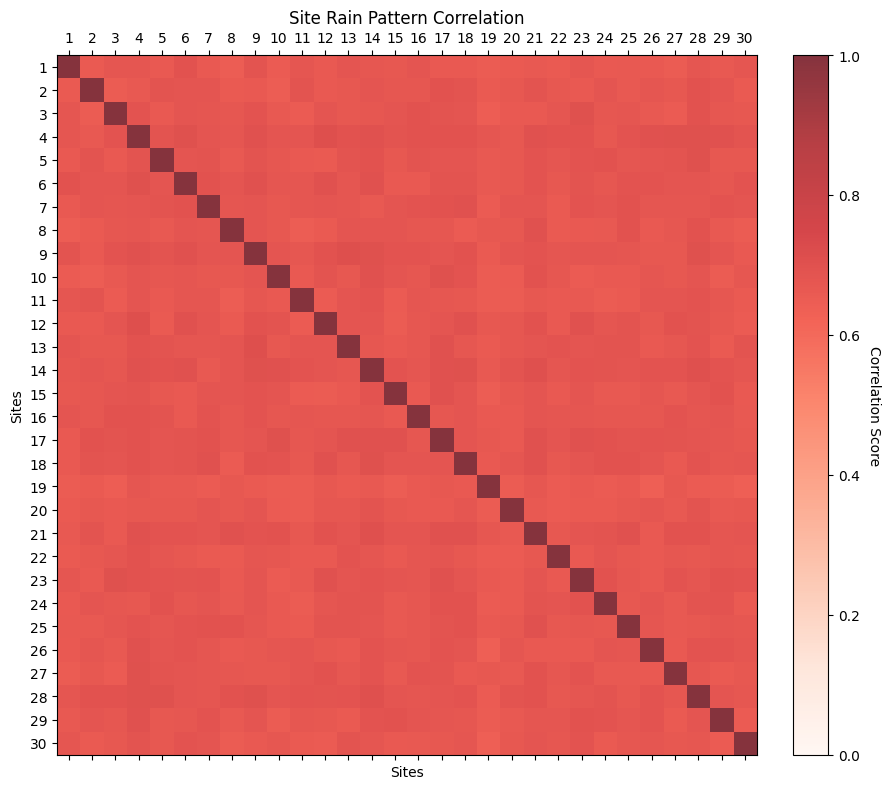

In [58]:
matrix = np.array(site_temp_pattern_correlation)
fig, ax = plt.subplots(figsize = (10, 8))

norm = mcolors.Normalize(vmin = 0, vmax = 1)

im = ax.matshow(matrix, cmap = plt.cm.Reds, norm = norm, alpha = 0.8)

# for i in range(matrix.shape[0]):
#     for j in range(matrix.shape[1]):
#         ax.text(x = j, y = i, s = matrix[i, j], va = "center", ha = "center", size = "small")

ax.set_xticks(range(matrix.shape[1]))
ax.set_yticks(range(matrix.shape[0]))

ax.set_xticklabels(range(1, 31))
ax.set_yticklabels(range(1, 31))

ax.set_xlabel("Sites", fontsize = 10)
ax.set_ylabel("Sites", fontsize = 10)

ax.set_title("Site Rain Pattern Correlation")

cbar = fig.colorbar(im, ax = ax, fraction=0.046, pad=0.04)
cbar.set_label("Correlation Score", rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

In [59]:
site_cement_choice_by_type = data.groupby(by = ["site_id", "cement_type"], as_index = False)["consumed_tonnes"].sum()
site_cement_choice_by_type.consumed_tonnes = site_cement_choice_by_type.consumed_tonnes.round()
site_cement_choice_by_type.head()

,site_id,cement_type,consumed_tonnes
0,SITE_001,CEM_I,11265.0
1,SITE_001,CEM_II,11512.0
2,SITE_001,CEM_III,10279.0
3,SITE_002,CEM_I,4288.0
4,SITE_002,CEM_II,4025.0


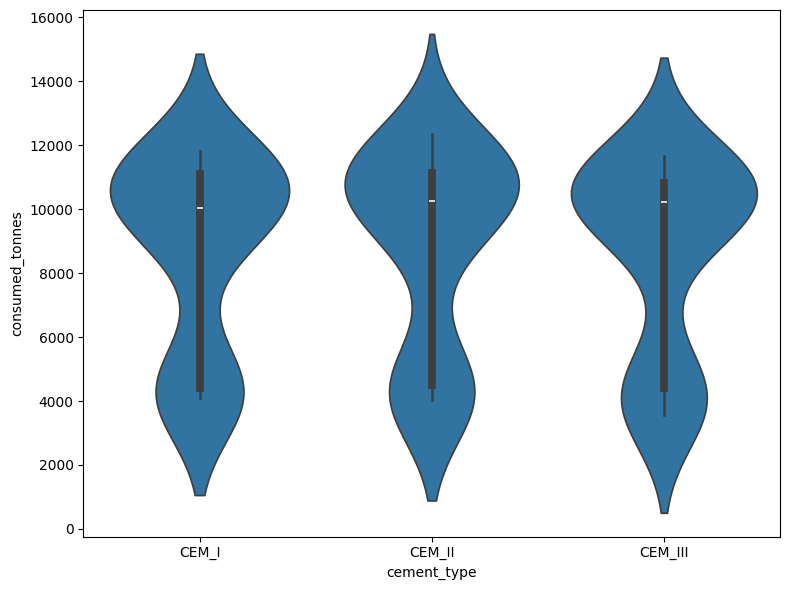

In [60]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.violinplot(data = site_cement_choice_by_type, x = "cement_type", y = "consumed_tonnes", ax = ax)

plt.tight_layout()
plt.show()

In [61]:
data.head()

,date,site_id,cement_type,rain_mm,avg_temp_c,planned_pour_tonnes,consumed_tonnes
0,2022-01-01,SITE_001,CEM_II,3.40,-3.10,43.18,34.54
1,2022-01-01,SITE_002,CEM_I,3.31,4.86,15.70,15.70
2,2022-01-01,SITE_003,CEM_II,2.85,21.19,57.45,57.45
3,2022-01-01,SITE_004,CEM_I,0.02,9.48,6.75,6.75
4,2022-01-01,SITE_005,CEM_II,29.77,23.52,42.42,0.00


In [62]:
data["delta"] = data["planned_pour_tonnes"] - data["consumed_tonnes"]

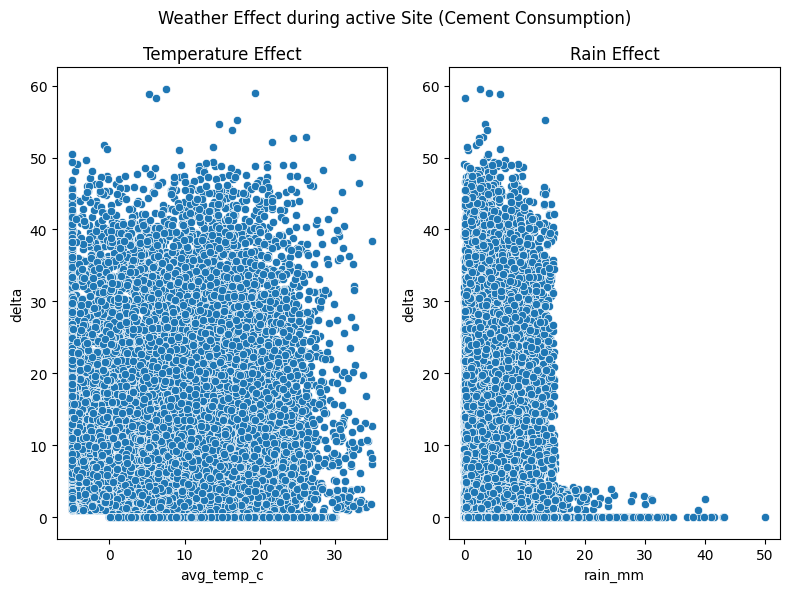

In [63]:
fig, ax = plt.subplots(1, 2, figsize = (8, 6))

sns.scatterplot(data = data.loc[data.consumed_tonnes > 0], x = "avg_temp_c", y = "delta", ax = ax[0])
sns.scatterplot(data = data.loc[data.consumed_tonnes > 0], x = "rain_mm", y = "delta", ax = ax[1])

plt.suptitle("Weather Effect during active Site (Cement Consumption)")

ax[0].set_title("Temperature Effect")
ax[1].set_title("Rain Effect")


plt.tight_layout()
plt.show()

In [64]:
data.loc[
    (data.consumed_tonnes > 0) &
    (data.rain_mm >= 15),
    ["planned_pour_tonnes", "consumed_tonnes", "delta"]
]

,planned_pour_tonnes,consumed_tonnes,delta
53,15.92,15.92,0.0
80,19.09,19.09,0.0
104,14.66,14.66,0.0
293,13.71,13.71,0.0
321,9.82,9.82,0.0
...,...,...,...
32463,15.42,15.42,0.0
32480,13.71,13.71,0.0
32540,16.87,16.87,0.0
32564,5.60,5.60,0.0


> IT SEEMS THAT WHEN THE CONSUMED CEMENT IS ALMOST EQUAL TO THE PLANNED POUR, THE PLANNED POUR IS LOW

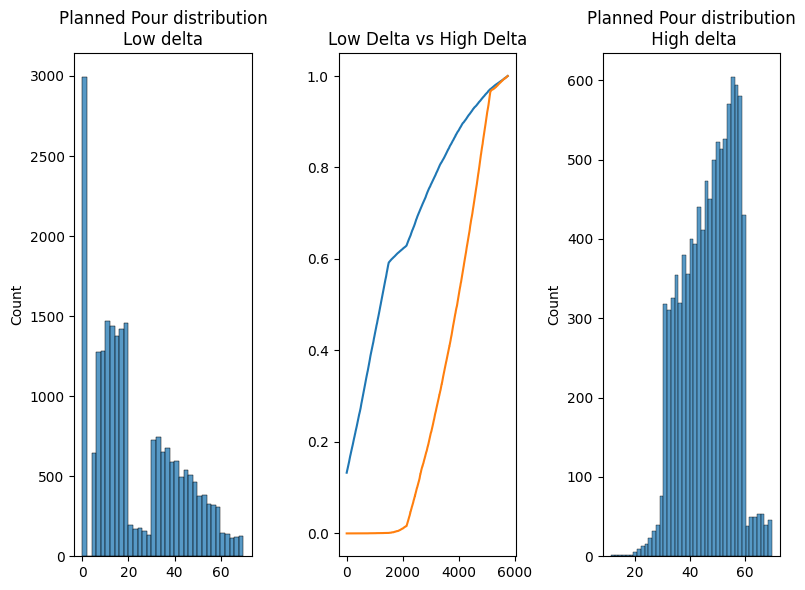

In [65]:
low_delta = data.loc[data.delta < 5, "planned_pour_tonnes"].values
high_delta = data.loc[data.delta > 5, "planned_pour_tonnes"].values

low_delta.size, high_delta.size

uniques = np.unique(np.concat([low_delta, high_delta]))
uniques.sort

low_cdf = np.array([low_delta[low_delta <= v].size / low_delta.size for v in uniques])
high_cdf = np.array([high_delta[high_delta <= v].size / high_delta.size for v in uniques])


fig, ax = plt.subplots(1, 3, figsize = (8, 6))

sns.histplot(low_delta, ax = ax[0])
sns.lineplot(x = np.arange(low_cdf.size), y = low_cdf, ax = ax[1])
sns.lineplot(x = np.arange(high_cdf.size), y = high_cdf, ax = ax[1])
sns.histplot(high_delta, ax = ax[2])

ax[0].set_title("Planned Pour distribution\nLow delta")
ax[1].set_title("Low Delta vs High Delta")
ax[2].set_title("Planned Pour distribution\n High delta")

plt.tight_layout()
plt.show()

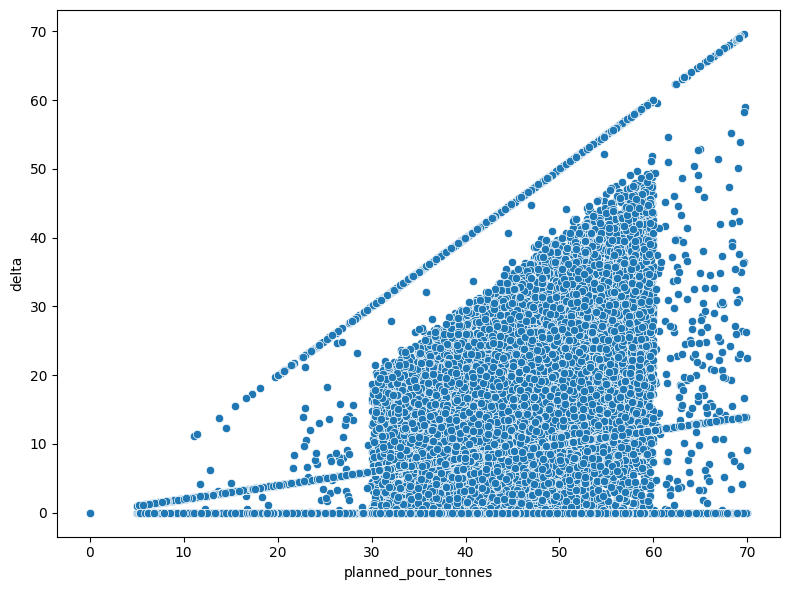

In [66]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.scatterplot(data = data, x = "planned_pour_tonnes", y = "delta", ax = ax)

plt.tight_layout()
plt.show()

In [67]:
data.head()

,date,site_id,cement_type,rain_mm,avg_temp_c,planned_pour_tonnes,consumed_tonnes,delta
0,2022-01-01,SITE_001,CEM_II,3.40,-3.10,43.18,34.54,8.64
1,2022-01-01,SITE_002,CEM_I,3.31,4.86,15.70,15.70,0.00
2,2022-01-01,SITE_003,CEM_II,2.85,21.19,57.45,57.45,0.00
3,2022-01-01,SITE_004,CEM_I,0.02,9.48,6.75,6.75,0.00
4,2022-01-01,SITE_005,CEM_II,29.77,23.52,42.42,0.00,42.42


In [68]:
def kpss_test(series: pd.Series) -> Tuple[float, float, str]:

    stat, p_value, _, _, = kpss(
        series, regression = "c"
    )

    decision = "non-stationary" if p_value < 0.05 else "stationary"

    return stat.round(3), p_value.round(3), decision

def adf_test(series: pd.Series) -> Tuple[float, float, str]:
    result = adfuller(series)
    stat, p_value = result[0].round(3), result[1].round(3)
    decision = "stationary" if p_value < 0.05 else "non-stationary"

    return stat, p_value, decision

In [69]:
def cement_usage_trend(site_id: str, cement_type: Literal["CEM_I", "CEM_II", "CEM_III"],
                       variable: Literal["consumed_tonnes", "planned_pour_tonnes"] = "consumed_tonnes",
                       cadence: Optional[str] = None) -> pd.DataFrame:

    query = f"""

                WITH date_range AS (
                    SELECT
                        *
                    FROM
                        generate_series(
                            DATE '{OPERATION_START_DATE}',
                            DATE '{OPERATION_END_DATE}',
                            INTERVAL '1 day'
                        ) AS date_range(date)
                ),
                site_data AS (
                    SELECT
                        CAST(date AS DATE) AS date,
                        {variable}
                    FROM
                        Operations
                    WHERE
                        site_id = '{site_id}'
                        AND
                        cement_type = '{cement_type}'
                    ORDER BY
                        date ASC
                ),
                full_data AS (
                    SELECT
                        dr.date,
                        COALESCE(sd.{variable}, 0) AS {variable}
                    FROM
                        date_range AS dr
                    LEFT JOIN
                        site_data AS sd
                    ON
                        dr.date = sd.date
                    ORDER BY
                        dr.date ASC
                )
                SELECT
                    time_bucket('{cadence}', date) AS week,
                    SUM({variable}) AS {variable}
                FROM
                    full_data
                GROUP BY 1
                ORDER BY 1;
            """

    return con.execute(query).df()


In [70]:
site_usage = cement_usage_trend("SITE_001", "CEM_I", "consumed_tonnes", cadence = "1 week")

In [71]:
kpss_candidates = []
adf_candidates = []

for site in sites:
    for cement in ["CEM_I", "CEM_II", "CEM_III"]:
        for variable in ["consumed_tonnes", "planned_pour_tonnes"]:
            for cadence in ["1 week", "2 weeks", "3 weeks", "4 weeks"]:
                usage_trend = cement_usage_trend(
                    site_id = site, cement_type = cement,
                    variable = variable, cadence = cadence
                )
                _, _, adf_decision = adf_test(usage_trend[variable])
                _, _, kpss_decision = kpss_test(usage_trend[variable])

                if kpss_decision == "non-stationary":
                    kpss_candidates.append(
                        {
                            "site_id": site,
                            "cement_type": cement,
                            "variable": variable,
                            "cadence": cadence
                        }
                    )
                if adf_decision == "non-stationary":
                    adf_candidates.append(
                        {
                            "site_id": site,
                            "cement_type": cement,
                            "variable": variable,
                            "cadence": cadence
                        }
                    )

In [72]:
len(kpss_candidates), len(adf_candidates)

(20, 29)

In [73]:
{cand["site_id"] for cand in kpss_candidates}

{'SITE_001',
 'SITE_006',
 'SITE_014',
 'SITE_017',
 'SITE_025',
 'SITE_026',
 'SITE_028'}

In [74]:
{cand["site_id"] for cand in adf_candidates}

{'SITE_004',
 'SITE_006',
 'SITE_007',
 'SITE_009',
 'SITE_010',
 'SITE_014',
 'SITE_015',
 'SITE_016',
 'SITE_017',
 'SITE_024',
 'SITE_027',
 'SITE_028',
 'SITE_030'}

In [75]:
{cand["site_id"] for cand in kpss_candidates}.intersection({cand["site_id"] for cand in adf_candidates})

{'SITE_006', 'SITE_014', 'SITE_017', 'SITE_028'}

In [76]:
set([", ".join(e.values()) for e in kpss_candidates]).intersection([", ".join(e.values()) for e in adf_candidates])

{'SITE_006, CEM_II, consumed_tonnes, 4 weeks',
 'SITE_028, CEM_I, planned_pour_tonnes, 2 weeks'}

In [77]:
def lag_correlation(series: pd.Series, nlags: int, alpha: float = 0.05) -> List[Tuple[int, float]]:

    coef_values = []
    pvalues = []
    lags = []
    for i in range(1, nlags + 1):
        coef, pvalue = pearsonr(
            series.shift(i).dropna().reset_index(drop = True),
            series.iloc[i:].reset_index(drop = True)
        )

        if pvalue < alpha:
            coef_values.append(coef.round(3))
            pvalues.append(pvalue.round(3))
            lags.append(i)

    result = pd.DataFrame(
        data = {
            "lags": lags,
            "coef": coef_values,
            "pvalue": pvalues,
        }
    )

    return result

In [78]:
kpss_candidates[6]

{'site_id': 'SITE_014',
 'cement_type': 'CEM_I',
 'variable': 'planned_pour_tonnes',
 'cadence': '3 weeks'}

In [79]:
usage_trend = cement_usage_trend(**kpss_candidates[4])
usage_trend.head()

,week,consumed_tonnes
0,2021-12-06,0.00
1,2022-01-03,199.96
2,2022-01-31,404.24
3,2022-02-28,369.10
4,2022-03-28,370.82


In [80]:
lag_correlation(
    usage_trend.consumed_tonnes,
    nlags = 15,
    alpha = 0.05
)

,lags,coef,pvalue
0,10,0.436,0.014


In [81]:
stl = STL(usage_trend.consumed_tonnes.values, period = 10, robust = True).fit()

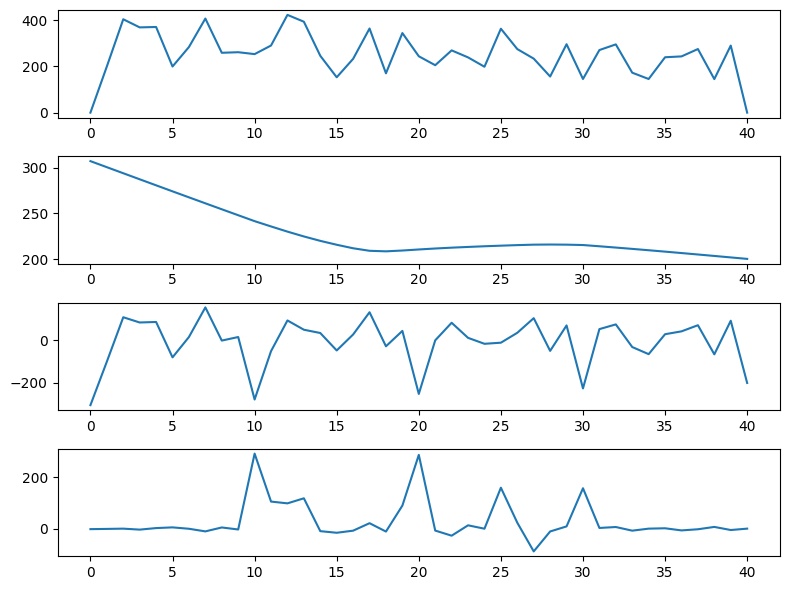

In [82]:
fig, ax = plt.subplots(4, 1, figsize = (8, 6))

sns.lineplot(usage_trend.consumed_tonnes.values, ax = ax[0])
sns.lineplot(stl.trend, ax = ax[1])
sns.lineplot(stl.seasonal, ax = ax[2])
sns.lineplot(stl.resid, ax = ax[3])

plt.tight_layout()
plt.show()

In [83]:
data.head()

,date,site_id,cement_type,rain_mm,avg_temp_c,planned_pour_tonnes,consumed_tonnes,delta
0,2022-01-01,SITE_001,CEM_II,3.40,-3.10,43.18,34.54,8.64
1,2022-01-01,SITE_002,CEM_I,3.31,4.86,15.70,15.70,0.00
2,2022-01-01,SITE_003,CEM_II,2.85,21.19,57.45,57.45,0.00
3,2022-01-01,SITE_004,CEM_I,0.02,9.48,6.75,6.75,0.00
4,2022-01-01,SITE_005,CEM_II,29.77,23.52,42.42,0.00,42.42


In [84]:
con.execute("SELECT * FROM Sites;").df()

,site_id,region,silo_capacity,behavior
0,SITE_001,North,448,aggressive
1,SITE_002,South,288,conservative
2,SITE_003,East,314,aggressive
3,SITE_004,South,472,conservative
4,SITE_005,South,230,aggressive
5,SITE_006,East,443,chaotic
6,SITE_007,East,485,aggressive
7,SITE_008,West,260,aggressive
8,SITE_009,East,352,conservative
9,SITE_010,West,158,aggressive


INVENTORY IS TRACKED BY SITE. NOT CEMENT SPECIFIC. CLOSING INVENTORY RECORDS TOTAL NUMBER OF AVAILABLE CEMENTS 

In [85]:
query = """

    WITH site_cement_sort AS (
        SELECT
            CAST(date AS DATE) AS date,
            site_id,
            cement_type,
            opening_inventory_tonnes,
            closing_inventory_tonnes,
            ROW_NUMBER() OVER (PARTITION BY site_id, cement_type ORDER BY date ASC) AS rank
        FROM
            Operations
    )

    SELECT
        current.date,
        current.site_id,
        current.cement_type,
        current.opening_inventory_tonnes,
        current.closing_inventory_tonnes,
        CASE
            WHEN current.opening_inventory_tonnes = previous.closing_inventory_tonnes THEN 1
            ELSE 0
        END AS consistency
    FROM
        site_cement_sort AS current
    JOIN
        site_cement_sort AS previous
    ON
        current.site_id = previous.site_id
        AND
        current.cement_type = previous.cement_type
        AND
        current.rank = previous.rank + 1
    ORDER BY
        current.site_id ASC,
        current.cement_type ASC,
        current.date ASC;
"""

site_consistency = con.execute(query).df()

In [86]:
site_consistency.head(10)

,date,site_id,cement_type,opening_inventory_tonnes,closing_inventory_tonnes,consistency
0,2022-01-04,SITE_001,CEM_I,47.06,32.64,0
1,2022-01-07,SITE_001,CEM_I,0.00,14.12,0
2,2022-01-08,SITE_001,CEM_I,14.12,0.00,1
3,2022-01-09,SITE_001,CEM_I,0.00,34.38,1
4,2022-01-13,SITE_001,CEM_I,44.66,16.67,0
5,2022-01-15,SITE_001,CEM_I,22.44,0.00,0
6,2022-01-24,SITE_001,CEM_I,7.22,2.98,0
7,2022-01-26,SITE_001,CEM_I,0.00,2.63,0
8,2022-01-27,SITE_001,CEM_I,2.63,0.00,1
9,2022-01-31,SITE_001,CEM_I,3.59,0.00,0


In [87]:
site_consistency.groupby(by = ["site_id"])["consistency"].mean().round(3).sort_values(ascending = False)

site_id
SITE_022    0.571
SITE_017    0.549
SITE_021    0.543
SITE_020    0.542
SITE_011    0.540
SITE_018    0.536
SITE_001    0.530
SITE_005    0.528
SITE_025    0.527
SITE_008    0.526
SITE_010    0.514
SITE_007    0.511
SITE_030    0.500
SITE_003    0.494
SITE_006    0.383
SITE_013    0.361
SITE_028    0.356
SITE_009    0.347
SITE_015    0.347
SITE_027    0.342
SITE_026    0.341
SITE_016    0.338
SITE_014    0.335
SITE_019    0.334
SITE_012    0.334
SITE_002    0.326
SITE_024    0.323
SITE_023    0.321
SITE_029    0.313
SITE_004    0.302
Name: consistency, dtype: float64

In [88]:
query = """

    WITH site_cement_sort AS (
        SELECT
            CAST(date AS DATE) AS date,
            site_id,
            cement_type,
            opening_inventory_tonnes,
            closing_inventory_tonnes,
            ROW_NUMBER() OVER (PARTITION BY site_id ORDER BY date ASC) AS rank
        FROM
            Operations
    )

    SELECT
        current.date,
        current.site_id,
        current.cement_type,
        current.opening_inventory_tonnes,
        current.closing_inventory_tonnes,
        CASE
            WHEN current.opening_inventory_tonnes = previous.closing_inventory_tonnes THEN 1
            ELSE 0
        END AS consistency
    FROM
        site_cement_sort AS current
    JOIN
        site_cement_sort AS previous
    ON
        current.site_id = previous.site_id
        AND
        current.rank = previous.rank + 1
    ORDER BY
        current.site_id ASC,
        current.date ASC;
"""

site_consistency = con.execute(query).df()

In [89]:
site_consistency.groupby(by = ["site_id"])["consistency"].mean().round(3).sort_values(ascending = False).value_counts()

consistency
1.0    30
Name: count, dtype: int64

WEIRD! IT SEEMS SILO CAPACITY ON SITES SEEMS TO BE INFINITE. CAUSE, WHAT! WONDER WHAT SILO CAPACITY IS FOR?

In [90]:
query = """

    WITH site_max_inventory AS (
        SELECT
            site_id,
            MAX(opening_inventory_tonnes) as max_inventory_capacity
        FROM
            Operations
        GROUP BY
            site_id
        ORDER BY
            max_inventory_capacity DESC
    )
    SELECT
        smi.site_id,
        s.behavior,
        smi.max_inventory_capacity
    FROM
        site_max_inventory AS smi
    JOIN
        Sites AS s
    ON
        s.site_id = smi.site_id
    ORDER BY
        smi.max_inventory_capacity DESC;
"""

site_max_inventory = con.execute(query).df()

In [91]:
site_max_inventory

,site_id,behavior,max_inventory_capacity
0,SITE_019,conservative,20646.18
1,SITE_015,conservative,20631.10
2,SITE_004,conservative,20500.79
3,SITE_029,conservative,20456.53
4,SITE_012,conservative,20456.03
5,SITE_009,conservative,20249.99
6,SITE_027,conservative,20000.39
7,SITE_002,conservative,19960.22
8,SITE_023,conservative,19198.47
9,SITE_016,chaotic,922.26


In [92]:
query = """

    SELECT
        site_id,
        MAX(deliveries_tonnes) as max_delivery
    FROM
        Operations
    GROUP BY
        site_id
    ORDER BY
        max_delivery DESC;
"""

site_max_delivery = con.execute(query).df()

In [93]:
site_max_delivery.head(10)

,site_id,max_delivery
0,SITE_025,50.00
1,SITE_026,49.99
2,SITE_002,49.99
3,SITE_011,49.99
4,SITE_012,49.99
5,SITE_027,49.99
6,SITE_028,49.99
7,SITE_001,49.99
8,SITE_022,49.99
9,SITE_005,49.99


In [94]:
site_max_delivery.max_delivery.value_counts()

max_delivery
49.99    10
49.98     5
49.95     4
49.96     3
49.93     3
49.92     3
50.00     1
49.97     1
Name: count, dtype: int64

In [95]:
query = """

    SELECT
        CAST(op.date AS DATE) AS date,
        op.site_id,
        s.behavior,
        op.closing_inventory_tonnes
    FROM
        Operations AS op
    JOIN
        Sites as s
    ON
        s.site_id = op.site_id
    ORDER BY
        op.site_id ASC,
        date ASC;
"""

site_inventory_management = con.execute(query).df()

In [96]:
site_inventory_management["inventory_growth"] = site_inventory_management.groupby(by = ["site_id"])["closing_inventory_tonnes"].transform(lambda x: x.diff())

In [97]:
site_inventory_management.head()

,date,site_id,behavior,closing_inventory_tonnes,inventory_growth
0,2022-01-01,SITE_001,aggressive,63.85,NaN
1,2022-01-02,SITE_001,aggressive,38.56,-25.29
2,2022-01-03,SITE_001,aggressive,47.06,8.50
3,2022-01-04,SITE_001,aggressive,32.64,-14.42
4,2022-01-05,SITE_001,aggressive,0.00,-32.64


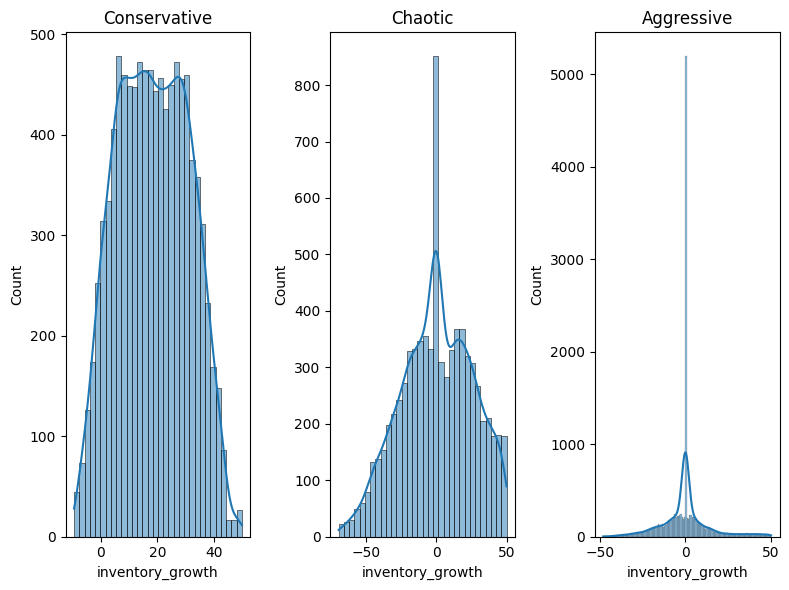

In [98]:
fig, ax = plt.subplots(1, 3, figsize = (8, 6))

sns.histplot(
    data = site_inventory_management.loc[site_inventory_management.behavior == "conservative"],
    x = "inventory_growth", kde = True, ax = ax[0]
)

sns.histplot(
    data = site_inventory_management.loc[site_inventory_management.behavior == "chaotic"],
    x = "inventory_growth", kde = True, ax = ax[1]
)

sns.histplot(
    data = site_inventory_management.loc[site_inventory_management.behavior == "aggressive"],
    x = "inventory_growth", kde = True, ax = ax[2]
)

ax[0].set_title("Conservative")
ax[1].set_title("Chaotic")
ax[2].set_title("Aggressive")

plt.tight_layout()
plt.show()

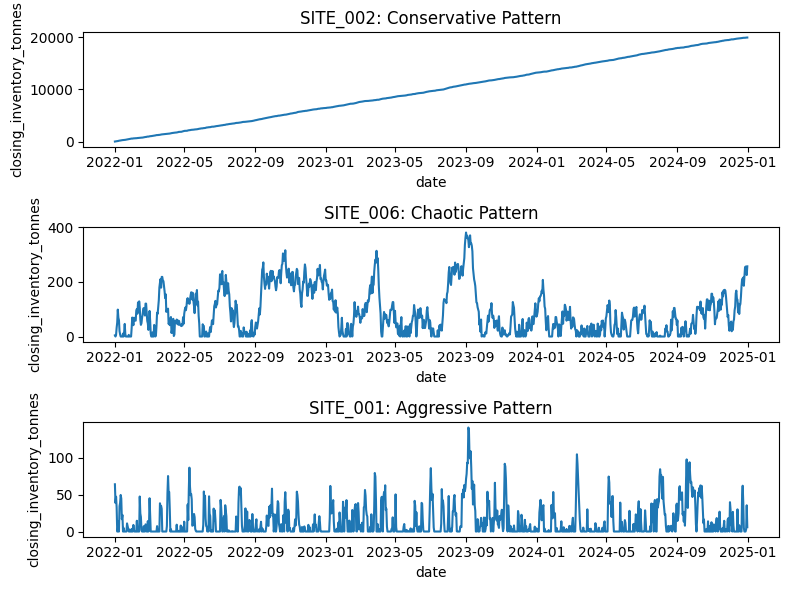

In [99]:
fig, ax = plt.subplots(3, 1, figsize = (8, 6))

sns.lineplot(
    data = site_inventory_management.loc[site_inventory_management.site_id == "SITE_002"],
    x = "date", y = "closing_inventory_tonnes", ax = ax[0]
)

sns.lineplot(
    data = site_inventory_management.loc[site_inventory_management.site_id == "SITE_006"],
    x = "date", y = "closing_inventory_tonnes", ax = ax[1]
)

sns.lineplot(
    data = site_inventory_management.loc[site_inventory_management.site_id == "SITE_001"],
    x = "date", y = "closing_inventory_tonnes", ax = ax[2]
)

ax[0].set_title("SITE_002: Conservative Pattern")
ax[1].set_title("SITE_006: Chaotic Pattern")
ax[2].set_title("SITE_001: Aggressive Pattern")

plt.tight_layout()
plt.show()

In [100]:
sites_df = con.execute("SELECT * FROM Sites;").df()

In [101]:
sites_df.head()

,site_id,region,silo_capacity,behavior
0,SITE_001,North,448,aggressive
1,SITE_002,South,288,conservative
2,SITE_003,East,314,aggressive
3,SITE_004,South,472,conservative
4,SITE_005,South,230,aggressive


In [102]:
behavioural_data = pd.merge(
    data.loc[:, ["site_id", "planned_pour_tonnes", "consumed_tonnes", "delta"]],
    sites_df.loc[:, ["site_id", "behavior"]],
    how = "inner",
    on = "site_id"
)

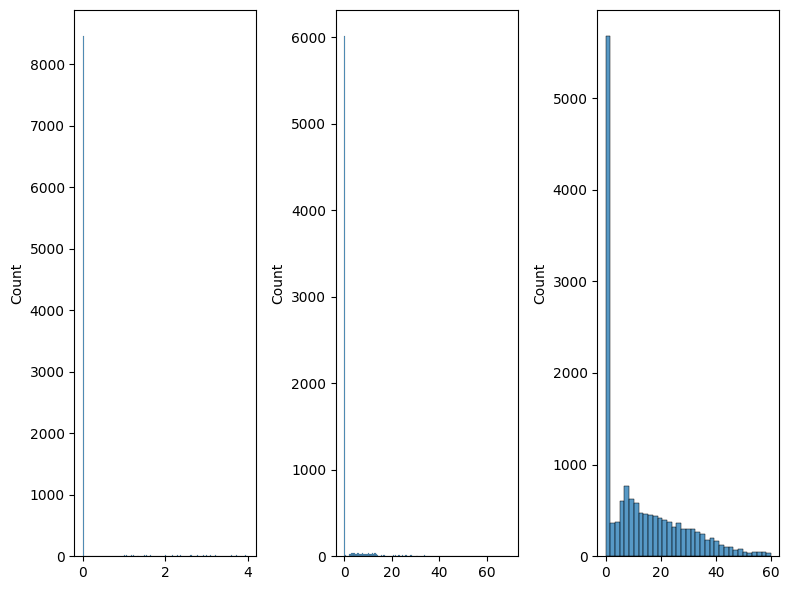

In [103]:
fig, ax = plt.subplots(1, 3, figsize = (8, 6))

sns.histplot(behavioural_data.loc[behavioural_data.behavior == "conservative", "delta"].values, ax = ax[0])
sns.histplot(behavioural_data.loc[behavioural_data.behavior == "chaotic", "delta"].values, ax = ax[1])
sns.histplot(behavioural_data.loc[behavioural_data.behavior == "aggressive", "delta"].values, ax = ax[2])

plt.tight_layout()
plt.show()

In [104]:
pd.cut(
    behavioural_data.loc[behavioural_data.behavior == "conservative", "delta"],
    bins = [-np.inf, 0, 2, 4, np.inf],
    labels = ["0", "2", "4", "inf"],
    include_lowest = True
).value_counts(normalize = True)

delta
0      0.857461
4      0.094079
2      0.048459
inf    0.000000
Name: proportion, dtype: float64

In [105]:
pd.cut(
    behavioural_data.loc[behavioural_data.behavior == "chaotic", "delta"],
    bins = [-np.inf, 0, 20, 40, np.inf],
    labels = ["0", "20", "40", "inf"],
    include_lowest = True
).value_counts(normalize = True)

delta
0      0.782325
20     0.145594
40     0.044317
inf    0.027763
Name: proportion, dtype: float64

In [106]:
pd.cut(
    behavioural_data.loc[behavioural_data.behavior == "aggressive", "delta"],
    bins = [-np.inf, 0, 20, 40, np.inf],
    labels = ["0", "20", "40", "inf"],
    include_lowest = True
).value_counts(normalize = True)

delta
20     0.374609
0      0.349909
40     0.221846
inf    0.053637
Name: proportion, dtype: float64

In [107]:
data["behavior"] = data["site_id"].map(sites_df.set_index("site_id")["behavior"].to_dict())

In [108]:
data.head()

,date,site_id,cement_type,rain_mm,avg_temp_c,planned_pour_tonnes,consumed_tonnes,delta,behavior
0,2022-01-01,SITE_001,CEM_II,3.40,-3.10,43.18,34.54,8.64,aggressive
1,2022-01-01,SITE_002,CEM_I,3.31,4.86,15.70,15.70,0.00,conservative
2,2022-01-01,SITE_003,CEM_II,2.85,21.19,57.45,57.45,0.00,aggressive
3,2022-01-01,SITE_004,CEM_I,0.02,9.48,6.75,6.75,0.00,conservative
4,2022-01-01,SITE_005,CEM_II,29.77,23.52,42.42,0.00,42.42,aggressive


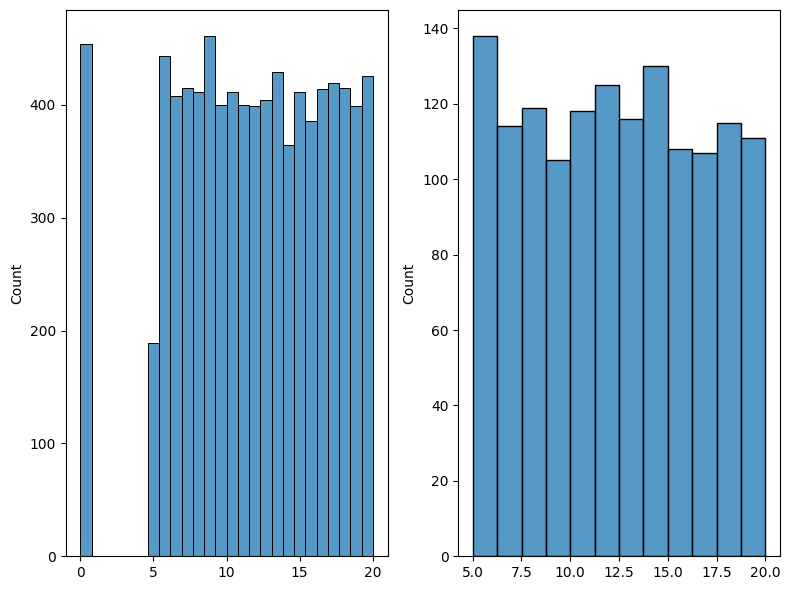

In [109]:
fig, ax = plt.subplots(1, 2, figsize = (8, 6))

sns.histplot(data.loc[(data.behavior == "conservative") & (data.delta == 0), "planned_pour_tonnes"].values, ax = ax[0])
sns.histplot(data.loc[(data.behavior == "conservative") & (data.delta > 0), "planned_pour_tonnes"].values, ax = ax[1])

plt.tight_layout()
plt.show()

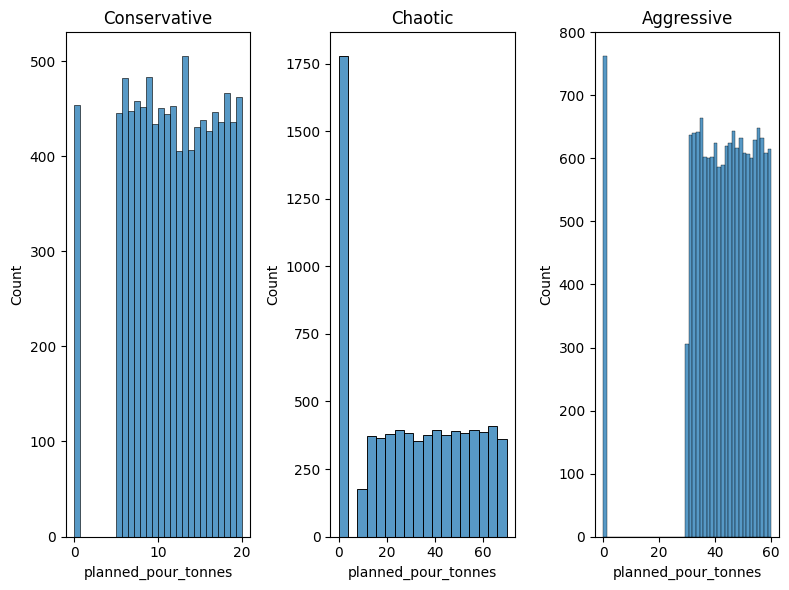

In [110]:
fig, ax = plt.subplots(1, 3, figsize = (8, 6))

sns.histplot(data.loc[data.behavior == "conservative", "planned_pour_tonnes"], ax = ax[0])
sns.histplot(data.loc[data.behavior == "chaotic", "planned_pour_tonnes"], ax = ax[1])
sns.histplot(data.loc[data.behavior == "aggressive", "planned_pour_tonnes"], ax = ax[2])

ax[0].set_title("Conservative")
ax[1].set_title("Chaotic")
ax[2].set_title("Aggressive")

plt.tight_layout()
plt.show()

In [111]:
data.head()

,date,site_id,cement_type,rain_mm,avg_temp_c,planned_pour_tonnes,consumed_tonnes,delta,behavior
0,2022-01-01,SITE_001,CEM_II,3.40,-3.10,43.18,34.54,8.64,aggressive
1,2022-01-01,SITE_002,CEM_I,3.31,4.86,15.70,15.70,0.00,conservative
2,2022-01-01,SITE_003,CEM_II,2.85,21.19,57.45,57.45,0.00,aggressive
3,2022-01-01,SITE_004,CEM_I,0.02,9.48,6.75,6.75,0.00,conservative
4,2022-01-01,SITE_005,CEM_II,29.77,23.52,42.42,0.00,42.42,aggressive


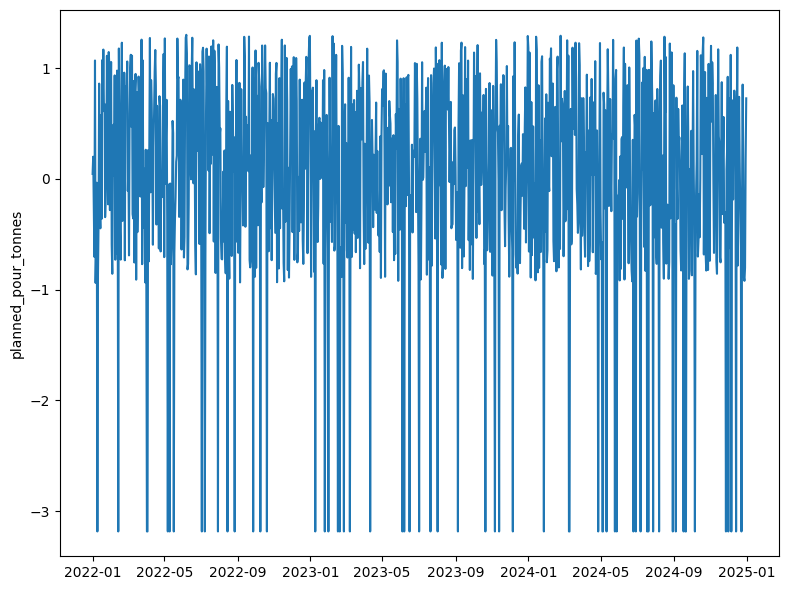

In [112]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.lineplot(
    x = data.loc[data.site_id == "SITE_001", "date"].values,
    y = (data.loc[data.site_id == "SITE_001", "planned_pour_tonnes"] - data.loc[data.site_id == "SITE_001", "planned_pour_tonnes"].mean()) / data.loc[data.site_id == "SITE_001", "planned_pour_tonnes"].std(),
    ax = ax
)

plt.tight_layout()
plt.show()

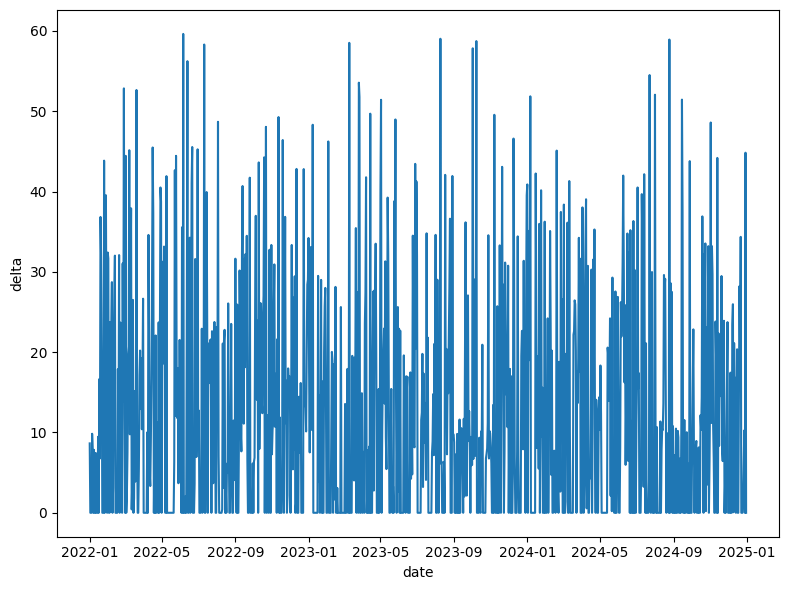

In [113]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.lineplot(
    data = data.loc[data.site_id == "SITE_001", ["date", "delta"]].reset_index(drop = True),
    x = "date",
    y = "delta",
    ax = ax
)

plt.tight_layout()
plt.show()

In [114]:
site_one = data.loc[data.site_id == "SITE_001", ["date", "delta", "planned_pour_tonnes"]].reset_index(drop = True)

In [115]:
site_one["delta_norm"] = (site_one["delta"] - site_one["delta"].mean()) / site_one["delta"].mean()

In [116]:
site_one["planned_pour_norm"] = (site_one["planned_pour_tonnes"] - site_one["planned_pour_tonnes"].mean()) / site_one["planned_pour_tonnes"].mean()

In [117]:
site_one["delta_norm"].corr(site_one["planned_pour_norm"])

np.float64(0.40494100525912535)

In [118]:
site_one["delta"].corr(site_one["planned_pour_tonnes"])

np.float64(0.4049410052591252)

In [119]:
site_one.set_index("date").resample("W")["planned_pour_tonnes"].sum()[1:-1].reset_index()

,date,planned_pour_tonnes
0,2022-01-09,234.47
1,2022-01-16,286.58
2,2022-01-23,346.98
3,2022-01-30,341.55
4,2022-02-06,307.16
...,...,...
151,2024-12-01,221.71
152,2024-12-08,281.74
153,2024-12-15,287.10
154,2024-12-22,307.57


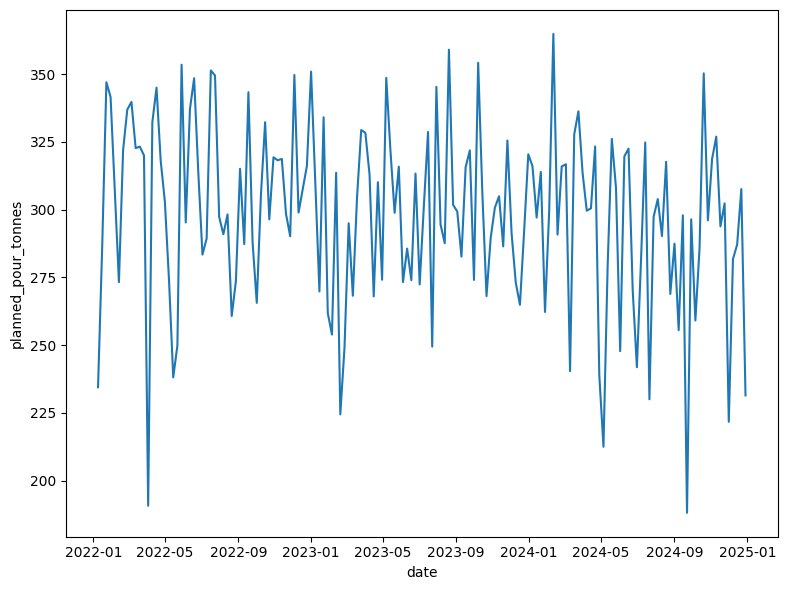

In [120]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.lineplot(
    data = site_one.set_index("date").resample("W")["planned_pour_tonnes"].sum()[1:-1].reset_index(),
    x = "date",
    y = "planned_pour_tonnes",
    ax = ax
)

plt.tight_layout()
plt.show()

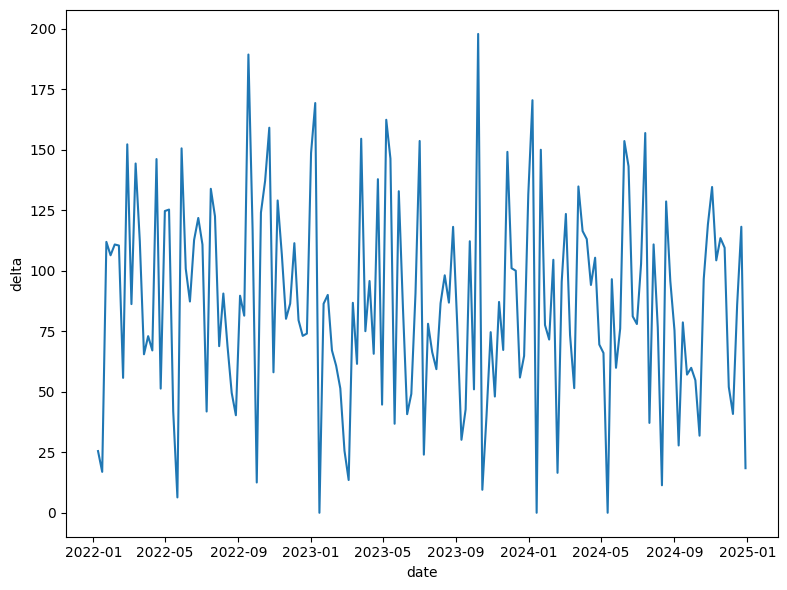

In [121]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.lineplot(
    data = site_one.set_index("date").resample("W")["delta"].sum()[1:-1].reset_index(),
    x = "date",
    y = "delta",
    ax = ax
)

plt.tight_layout()
plt.show()

In [122]:
site_one.set_index("date").resample("W")["delta"].sum()[1:-1].corr(
    site_one.set_index("date").resample("W")["planned_pour_tonnes"].sum()[1:-1]
)

np.float64(0.5237534826653604)

In [123]:
consumed = data.loc[data.site_id == "SITE_001", ["date", "consumed_tonnes"]].set_index("date").resample("W")["consumed_tonnes"].sum()

In [124]:
planned = data.loc[data.site_id == "SITE_001", ["date", "planned_pour_tonnes"]].set_index("date").resample("W")["planned_pour_tonnes"].sum()

In [219]:
consumed.corr(planned)

np.float64(0.45639563301558483)

PREDICTING RARE HEAVY STORM (>= 15MM)

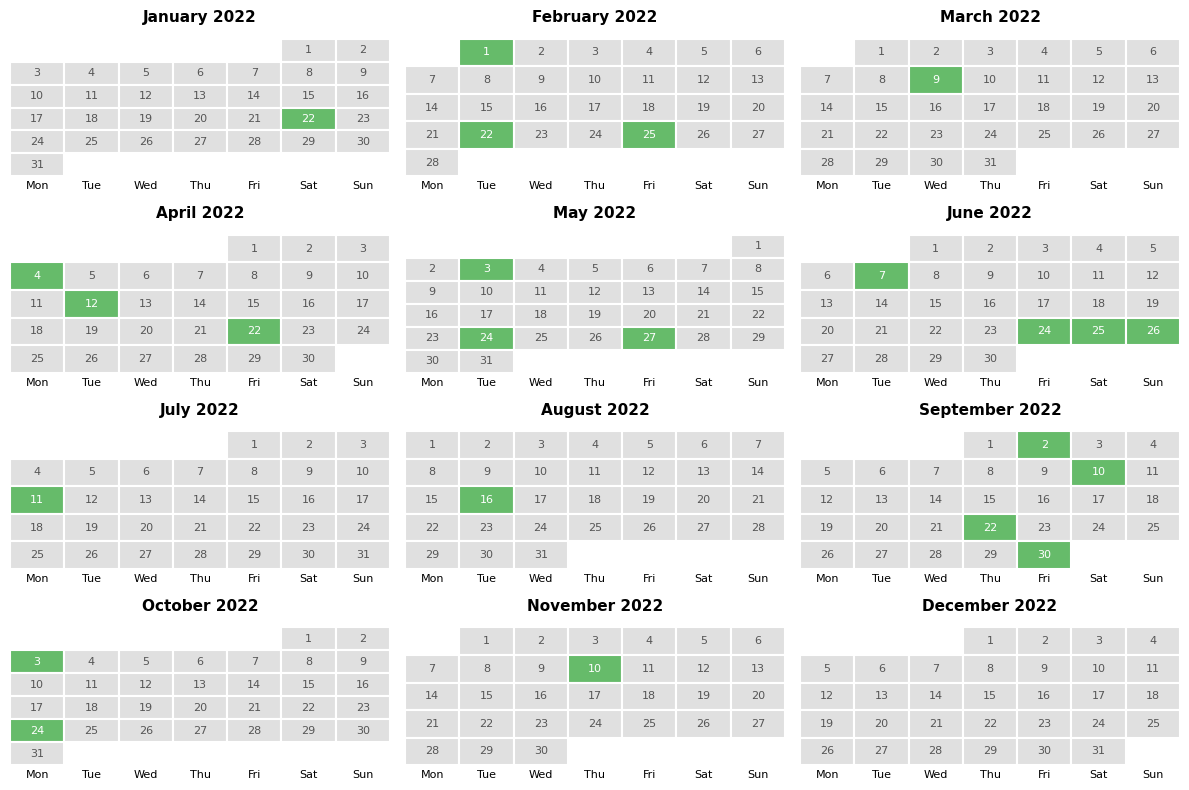

In [125]:
calendar_plot_binary(
    data.loc[(data.site_id == "SITE_026") & (data.date.dt.year == 2022), "date"],
    data.loc[(data.site_id == "SITE_026") & (data.date.dt.year == 2022), "rain_mm"].apply(lambda x: 1 if x >= 15 else 0),
    cmap = ListedColormap(
        ["#E0E0E0", "#66BB6A"]
    )
)

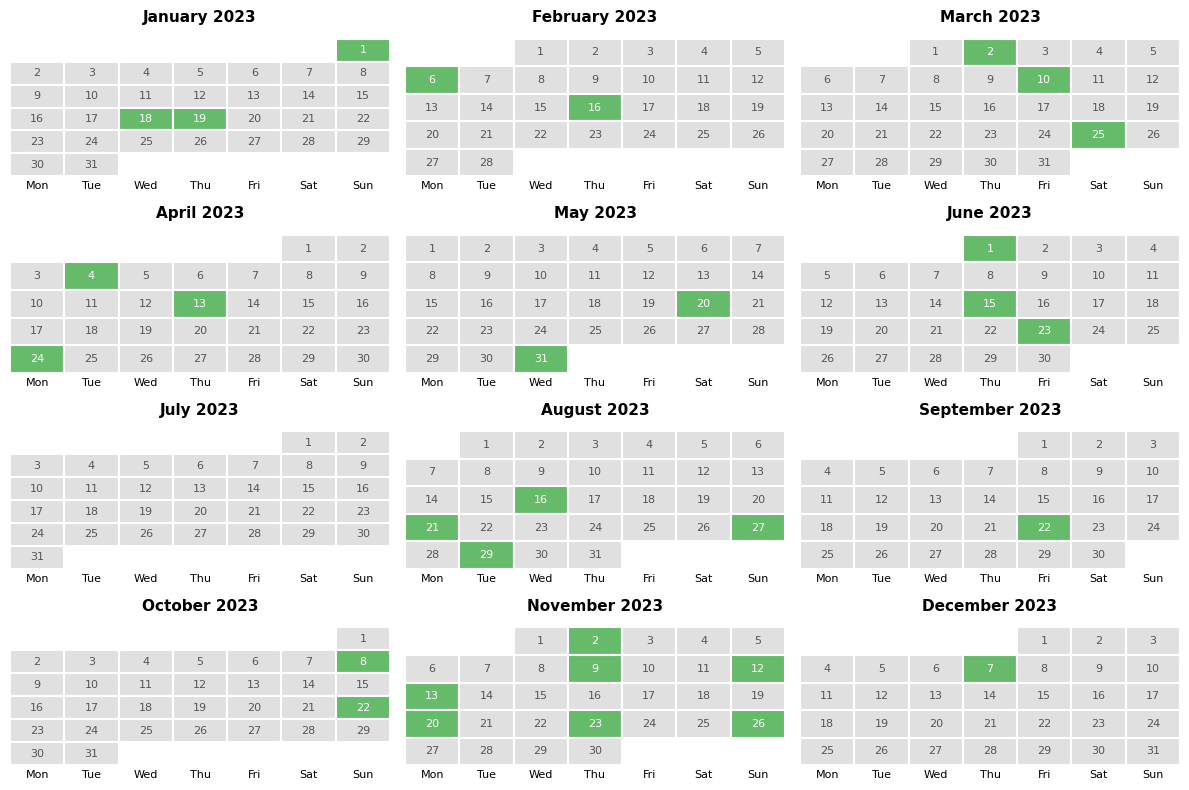

In [126]:
calendar_plot_binary(
    data.loc[(data.site_id == "SITE_026") & (data.date.dt.year == 2023), "date"],
    data.loc[(data.site_id == "SITE_026") & (data.date.dt.year == 2023), "rain_mm"].apply(lambda x: 1 if x >= 15 else 0),
    cmap = ListedColormap(
        ["#E0E0E0", "#66BB6A"]
    )
)

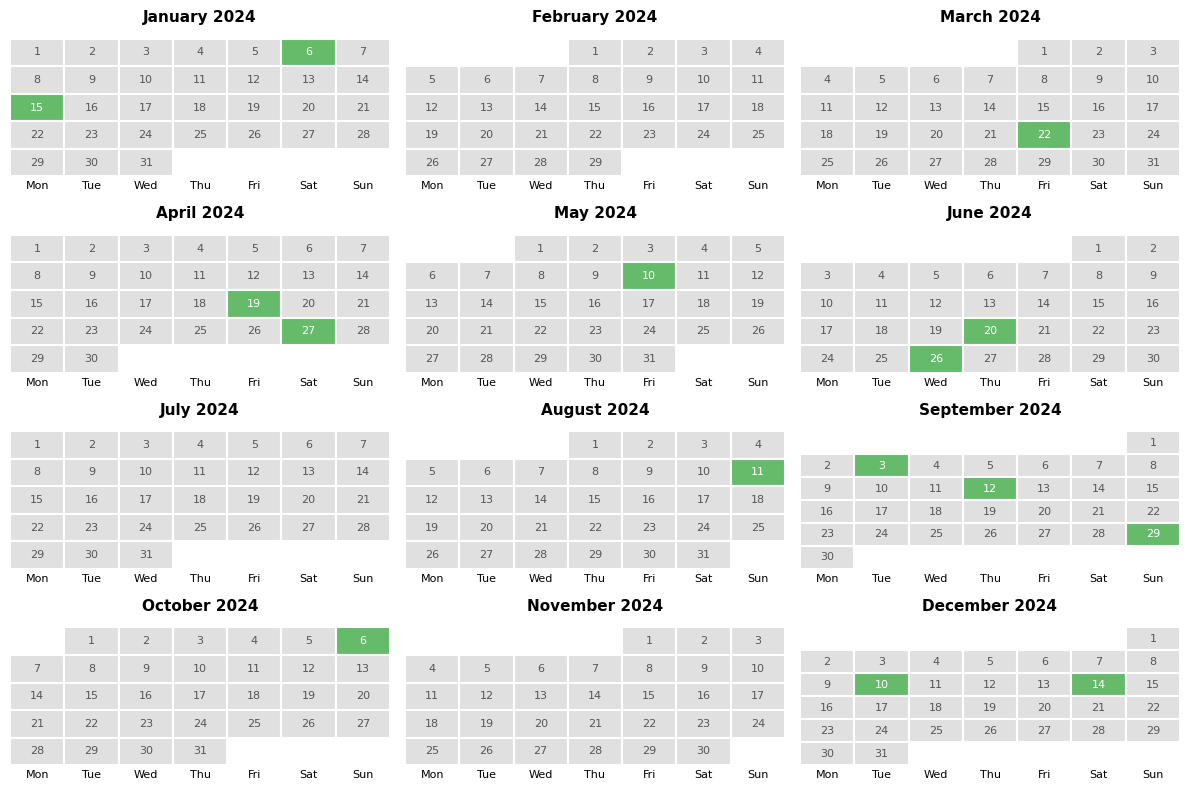

In [127]:
calendar_plot_binary(
    data.loc[(data.site_id == "SITE_026") & (data.date.dt.year == 2024), "date"],
    data.loc[(data.site_id == "SITE_026") & (data.date.dt.year == 2024), "rain_mm"].apply(lambda x: 1 if x >= 15 else 0),
    cmap = ListedColormap(
        ["#E0E0E0", "#66BB6A"]
    )
)

In [235]:
data.loc[data.rain_mm >= 15, "site_id"].value_counts(normalize = True)

site_id
SITE_026    0.042971
SITE_003    0.041743
SITE_004    0.036832
SITE_012    0.036832
SITE_009    0.036832
SITE_019    0.036219
SITE_025    0.035605
SITE_027    0.035605
SITE_011    0.035605
SITE_007    0.034991
SITE_030    0.034991
SITE_017    0.034991
SITE_021    0.034991
SITE_001    0.034991
SITE_024    0.034377
SITE_015    0.034377
SITE_016    0.033763
SITE_029    0.033149
SITE_028    0.032535
SITE_022    0.031921
SITE_010    0.031921
SITE_023    0.031921
SITE_005    0.031308
SITE_008    0.031308
SITE_013    0.030694
SITE_018    0.030694
SITE_014    0.030694
SITE_020    0.026397
SITE_006    0.024555
SITE_002    0.017188
Name: proportion, dtype: float64

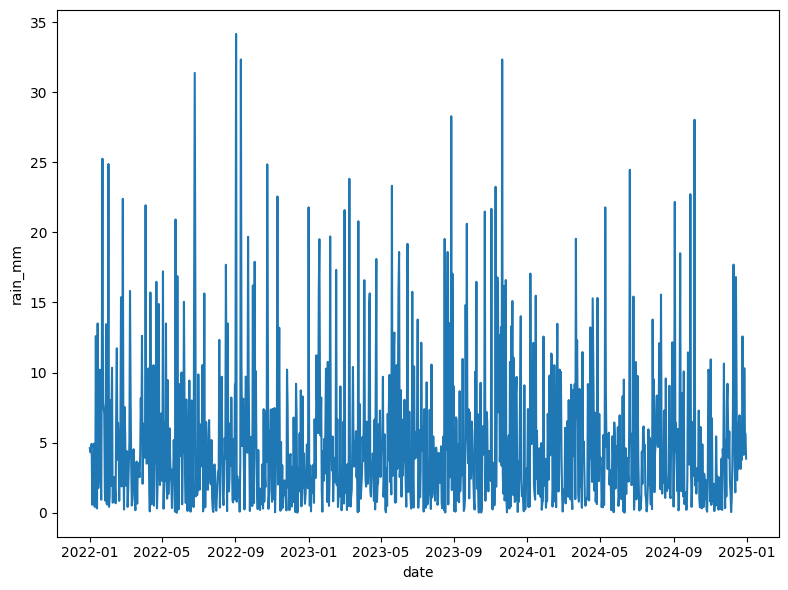

In [236]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.lineplot(data = data.loc[data.site_id == "SITE_026", ["date", "rain_mm"]], x = "date", y = "rain_mm", ax = ax)

plt.tight_layout()
plt.show()

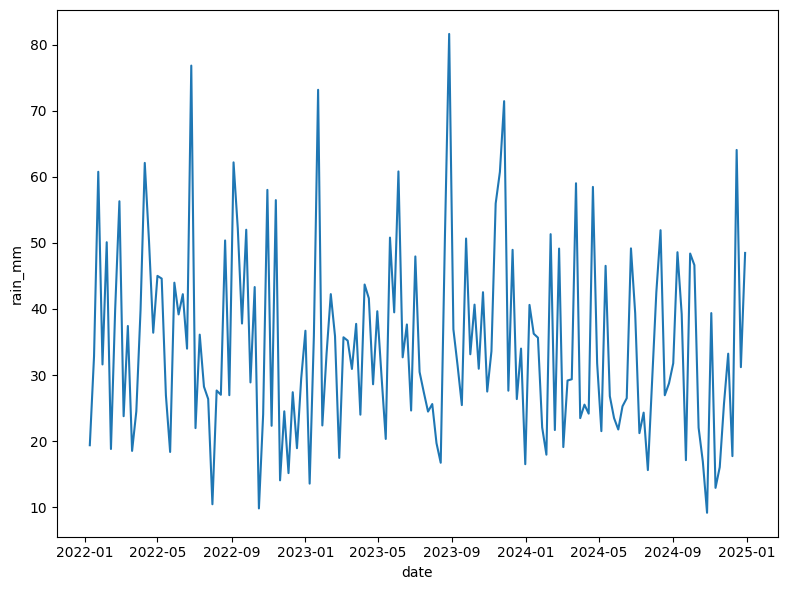

In [132]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.lineplot(
    data = data.loc[data.site_id == "SITE_026", ["date", "rain_mm"]].set_index("date").resample("W")["rain_mm"].sum()[1:-1].reset_index(),
    x = "date",
    y = "rain_mm", ax = ax
)

plt.tight_layout()
plt.show()

In [137]:
kpss_test(
    data.loc[data.site_id == "SITE_026", ["date", "rain_mm"]].set_index("date").resample("W")["rain_mm"].sum()[1:-1]
)

(np.float64(0.184), np.float64(0.1), 'stationary')

In [139]:
lag_correlation(
    data.loc[data.site_id == "SITE_026", ["date", "rain_mm"]].set_index("date").resample("W")["rain_mm"].sum()[1:-1],
    nlags = 60,
    alpha = 0.05
)

,lags,coef,pvalue
0,20,0.212,0.013


In [142]:
stl = STL(
    data.loc[data.site_id == "SITE_026", ["date", "rain_mm"]].set_index("date").resample("W")["rain_mm"].sum()[1:-1],
    period = 20,
    robust = True
).fit()

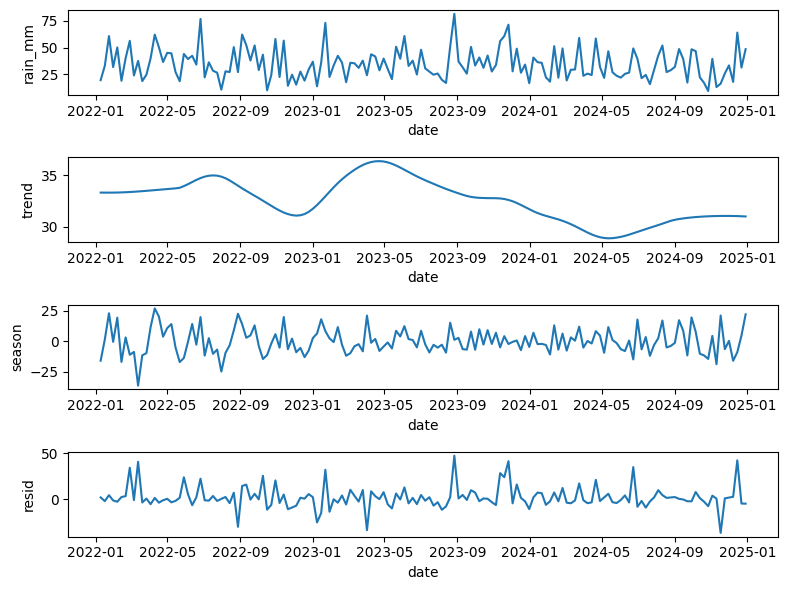

In [143]:
fig, ax = plt.subplots(4, 1, figsize = (8, 6))

sns.lineplot(
    data.loc[data.site_id == "SITE_026", ["date", "rain_mm"]].set_index("date").resample("W")["rain_mm"].sum()[1:-1],
    ax = ax[0]
)
sns.lineplot(stl.trend, ax = ax[1])
sns.lineplot(stl.seasonal, ax = ax[2])
sns.lineplot(stl.resid, ax = ax[3])

plt.tight_layout()
plt.show()

In [168]:
sum_rain_mm = (
    data.set_index('date').groupby("site_id")
    .resample("W")["rain_mm"].sum()
    .rename("sum_rain_mm").reset_index()
)

max_rain_mm = (
    data.set_index('date').groupby("site_id")
    .resample("W")["rain_mm"].max()
    .rename("max_rain_mm").reset_index()
)

site_rain_df = pd.merge(
    sum_rain_mm,
    max_rain_mm,
    how = "inner",
    on = ["site_id", "date"]
)

site_rain_df.head()

,site_id,date,sum_rain_mm,max_rain_mm
0,SITE_001,2022-01-02,6.63,3.40
1,SITE_001,2022-01-09,19.14,8.25
2,SITE_001,2022-01-16,23.61,5.71
3,SITE_001,2022-01-23,22.81,6.23
4,SITE_001,2022-01-30,49.15,13.76


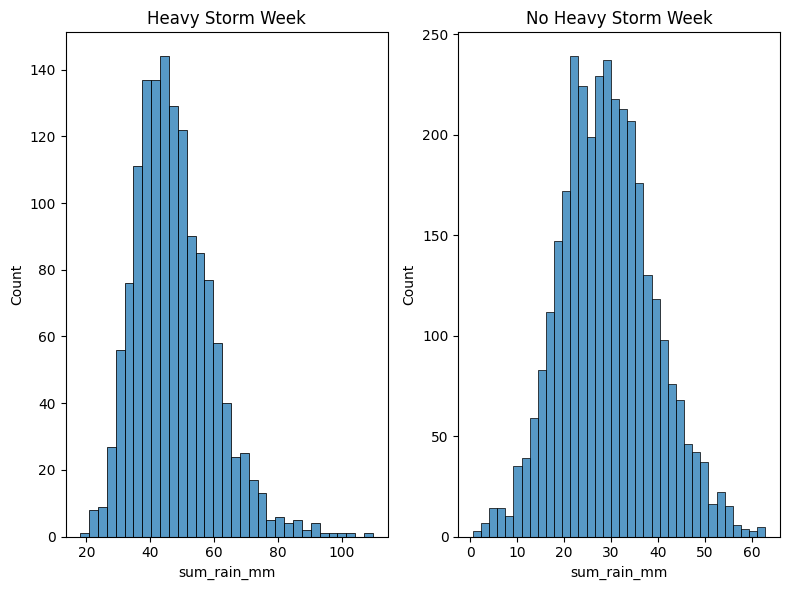

In [173]:
fig, ax = plt.subplots(1, 2, figsize = (8, 6))

sns.histplot(site_rain_df.loc[site_rain_df.max_rain_mm >= 15, "sum_rain_mm"], ax = ax[0])
sns.histplot(site_rain_df.loc[site_rain_df.max_rain_mm < 15, "sum_rain_mm"], ax = ax[1])

ax[0].set_title("Heavy Storm Week")
ax[1].set_title("No Heavy Storm Week")

plt.tight_layout()
plt.show()

In [174]:
site_rain_df.head()

,site_id,date,sum_rain_mm,max_rain_mm
0,SITE_001,2022-01-02,6.63,3.40
1,SITE_001,2022-01-09,19.14,8.25
2,SITE_001,2022-01-16,23.61,5.71
3,SITE_001,2022-01-23,22.81,6.23
4,SITE_001,2022-01-30,49.15,13.76


In [175]:
site_rain_df.loc[site_rain_df.site_id == "SITE_001"].shape

(158, 4)

In [179]:
56 * 2

112

In [169]:
site_rain_df.loc[site_rain_df.site_id == "SITE_026"].head(10)

,site_id,date,sum_rain_mm,max_rain_mm
3950,SITE_026,2022-01-02,8.92,4.61
3951,SITE_026,2022-01-09,19.38,4.93
3952,SITE_026,2022-01-16,32.85,13.50
3953,SITE_026,2022-01-23,60.75,25.25
3954,SITE_026,2022-01-30,31.60,13.45
3955,SITE_026,2022-02-06,50.09,24.87
3956,SITE_026,2022-02-13,18.81,10.34
3957,SITE_026,2022-02-20,39.95,11.73
3958,SITE_026,2022-02-27,56.29,22.39
3959,SITE_026,2022-03-06,23.77,7.53


In [171]:
data.loc[data.site_id == "SITE_026"].set_index('date').resample('W')["rain_mm"].max()

date
2022-01-02     4.61
2022-01-09     4.93
2022-01-16    13.50
2022-01-23    25.25
2022-01-30    13.45
              ...  
2024-12-08     5.80
2024-12-15    17.70
2024-12-22     6.95
2024-12-29    12.58
2025-01-05     5.62
Freq: W-SUN, Name: rain_mm, Length: 158, dtype: float64

In [234]:
data.loc[data.rain_mm >= 15].shape[0] / data.shape[0]

0.04954379562043796

In [226]:
data.loc[(data.rain_mm >= 15) & (data.planned_pour_tonnes > 0)].shape[0]

1488

In [229]:
data.loc[(data.rain_mm >= 15) & (data.planned_pour_tonnes > 0) & (data.consumed_tonnes == 0)].shape[0]

964

In [228]:
data.loc[(data.rain_mm < 15) & (data.planned_pour_tonnes > 0)].shape[0]

28399

In [230]:
data.loc[(data.rain_mm < 15) & (data.planned_pour_tonnes > 0) & (data.consumed_tonnes == 0)].shape[0]

46

In [162]:
(
    data.loc[data.behavior == "chaotic"].shape[0],
    data.loc[data.behavior == "conservative"].shape[0],
    data.loc[data.behavior == "aggressive"].shape[0]
)

(7672, 9864, 15344)

In [106]:
site_one = con.execute(" SELECT * FROM Operations WHERE site_id == 'SITE_001' ORDER BY date::DATE ASC;  ").df()

In [114]:
site_one.loc[
    :30,
    [
        "cement_type", "consumed_tonnes",
        "opening_inventory_tonnes", "deliveries_tonnes",
        "closing_inventory_tonnes"
    ]
]

,cement_type,consumed_tonnes,opening_inventory_tonnes,deliveries_tonnes,closing_inventory_tonnes
0,CEM_II,34.54,52.56,45.83,63.85
1,CEM_I,45.26,63.85,19.97,38.56
2,CEM_III,38.69,38.56,47.19,47.06
3,CEM_I,33.16,47.06,18.74,32.64
4,CEM_III,47.04,32.64,14.40,0.00
5,CEM_II,22.19,0.00,22.19,0.00
6,CEM_I,33.60,0.00,47.72,14.12
7,CEM_I,34.28,14.12,20.16,0.00
8,CEM_I,0.00,0.00,34.38,34.38
9,CEM_II,30.99,34.38,35.37,38.76


In [220]:
data.head()

,date,site_id,cement_type,rain_mm,avg_temp_c,planned_pour_tonnes,consumed_tonnes,delta,behavior
0,2022-01-01,SITE_001,CEM_II,3.40,-3.10,43.18,34.54,8.64,aggressive
1,2022-01-01,SITE_002,CEM_I,3.31,4.86,15.70,15.70,0.00,conservative
2,2022-01-01,SITE_003,CEM_II,2.85,21.19,57.45,57.45,0.00,aggressive
3,2022-01-01,SITE_004,CEM_I,0.02,9.48,6.75,6.75,0.00,conservative
4,2022-01-01,SITE_005,CEM_II,29.77,23.52,42.42,0.00,42.42,aggressive


In [221]:
data.shape

(32880, 9)

In [121]:
site_df = data.groupby(by = ["site_id", "date"], as_index = False)["planned_pour_tonnes"].sum()

In [122]:
site_df.head()

,site_id,date,planned_pour_tonnes
0,SITE_001,2022-01-01,43.18
1,SITE_001,2022-01-02,45.26
2,SITE_001,2022-01-03,38.69
3,SITE_001,2022-01-04,33.16
4,SITE_001,2022-01-05,56.88


In [127]:
site_df.loc[site_df.site_id == "SITE_001"].set_index("date").resample("W")["planned_pour_tonnes"].sum().reset_index()

,date,planned_pour_tonnes
0,2022-01-02,88.44
1,2022-01-09,234.47
2,2022-01-16,286.58
3,2022-01-23,346.98
4,2022-01-30,341.55
...,...,...
153,2024-12-08,281.74
154,2024-12-15,287.10
155,2024-12-22,307.57
156,2024-12-29,231.44


In [139]:
adf_test(
    site_df.loc[site_df.site_id == "SITE_001"].set_index("date").resample("W")["planned_pour_tonnes"].sum()
)

(np.float64(-10.644), np.float64(0.0), 'stationary')

In [138]:
kpss_test(
    site_df.loc[site_df.site_id == "SITE_001"].set_index("date").resample("W")["planned_pour_tonnes"].sum()
)

(np.float64(0.432), np.float64(0.063), 'stationary')

In [177]:
lag_correlation(
    site_df.loc[site_df.site_id == "SITE_001"].set_index("date").resample("1W")["planned_pour_tonnes"].sum(),
    nlags = 60, alpha = 0.05
)

,lags,coef,pvalue
0,1,0.165,0.039
1,13,0.183,0.028
2,19,0.200,0.018
3,20,0.206,0.016
4,29,-0.175,0.047
5,53,-0.203,0.038


In [327]:
stl = STL(
    site_df.loc[site_df.site_id == "SITE_001"].set_index("date").resample("1W")["planned_pour_tonnes"].sum().values,
    period = 19,
    robust = True
).fit()

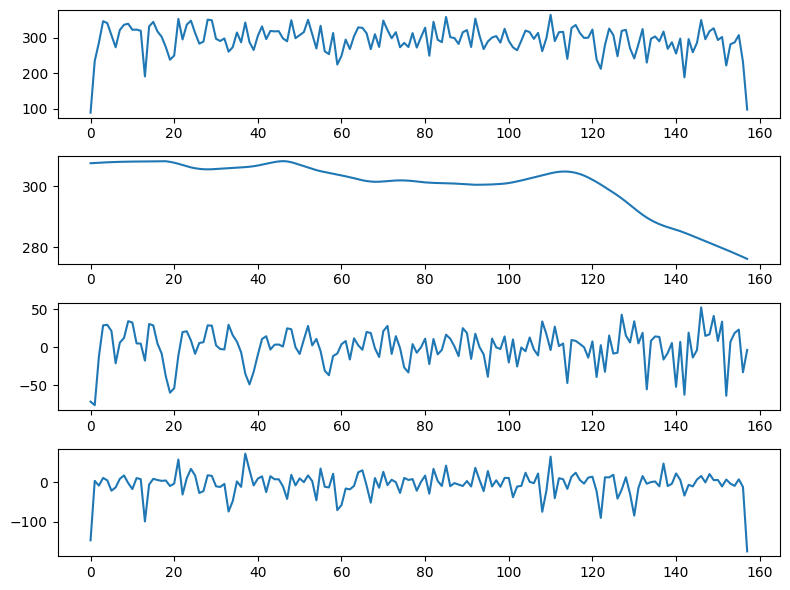

In [328]:
fig, ax = plt.subplots(4, 1, figsize = (8, 6))

sns.lineplot(site_df.loc[site_df.site_id == "SITE_001"].set_index("date").resample("1W")["planned_pour_tonnes"].sum().values, ax = ax[0])
sns.lineplot(stl.trend, ax = ax[1])
sns.lineplot(stl.seasonal, ax = ax[2])
sns.lineplot(stl.resid, ax = ax[3])

plt.tight_layout()
plt.show()

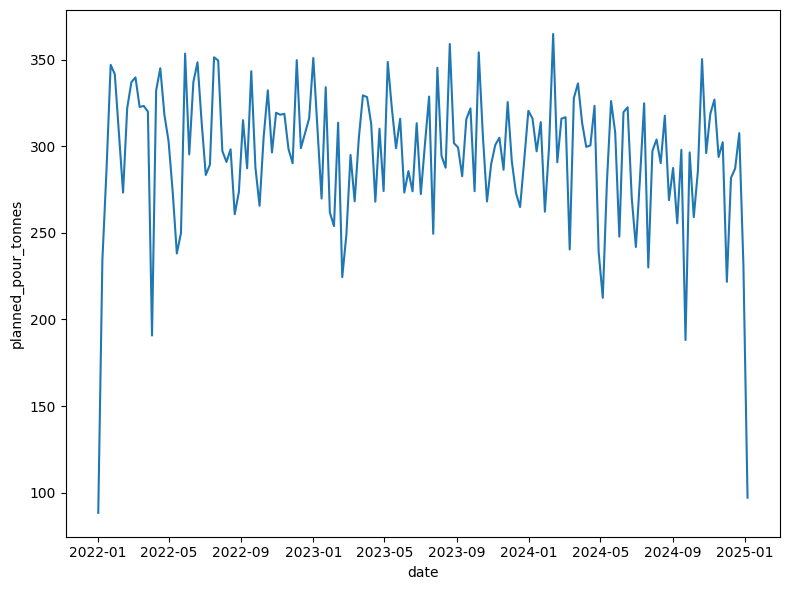

In [176]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.lineplot(data = site_df.loc[site_df.site_id == "SITE_001"].set_index("date").resample("1W")["planned_pour_tonnes"].sum().reset_index(),
             x = "date", y = "planned_pour_tonnes", ax = ax)

plt.tight_layout()
plt.show()

In [173]:
site_one["week_end"] = pd.to_datetime(site_one.date).dt.to_period("3W").astype(str).str.split("/").str[1]

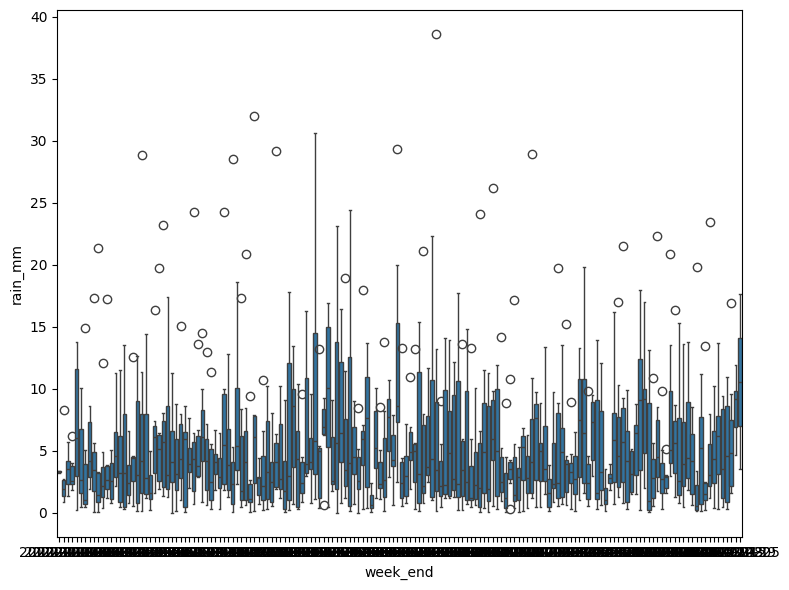

In [175]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.boxplot(
    data = site_one.loc[:, ["week_end", "rain_mm"]],
    x = "week_end", y = "rain_mm", ax = ax
)

plt.tight_layout()
plt.show()

In [321]:
site_one["heavy_rain"] = site_one.rain_mm > 3

In [324]:
site_one.groupby(by = ["week_end"])["rain_mm"].sum().reset_index()

,week_end,rain_mm
0,2022-01-02,6.63
1,2022-01-09,19.14
2,2022-01-16,23.61
3,2022-01-23,22.81
4,2022-01-30,49.15
...,...,...
153,2024-12-08,32.66
154,2024-12-15,34.77
155,2024-12-22,42.66
156,2024-12-29,59.27


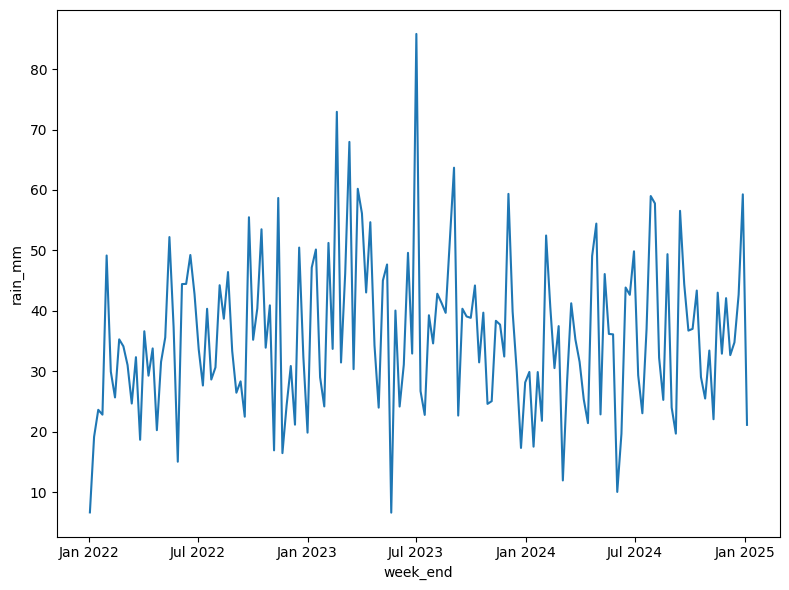

In [326]:
fig, ax = plt.subplots(figsize = (8, 6))

fdata = site_one.groupby(by = ["week_end"])["rain_mm"].sum().reset_index()

fdata.week_end = pd.to_datetime(fdata.week_end)

sns.lineplot(
    data = fdata,
    x = "week_end", y = "rain_mm", ax = ax
)

ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()

In [291]:
custom_function = lambda x: np.log((3 * (x ** 3)) + (5 * (x ** 2)) - (10 * x)) * np.cos(np.pi * x / 180)

In [292]:
x = np.arange(0, 1440, 4)
y = np.array([custom_function(i) for i in range(0, 1440, 4)])

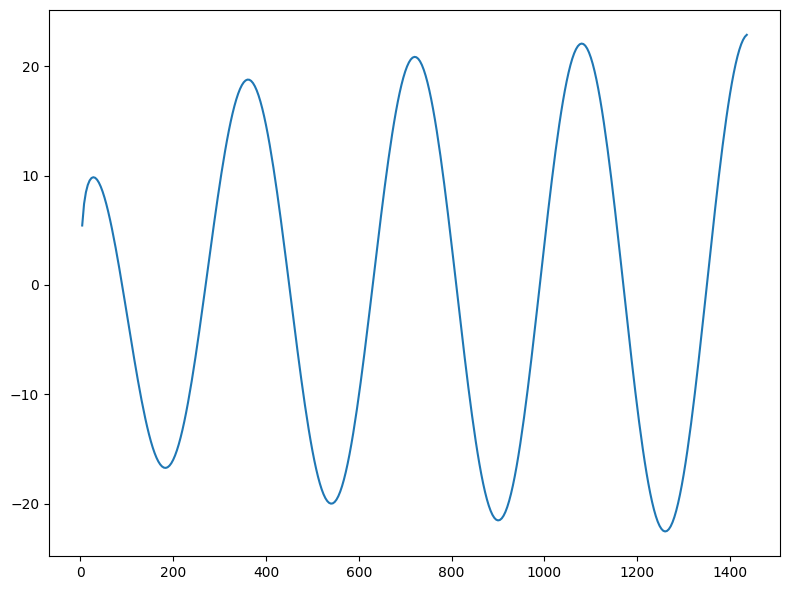

In [293]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.lineplot(x = x, y = y, ax = ax)

plt.tight_layout()
plt.show()

In [253]:
result = kpss(y)

In [254]:
result

(np.float64(0.27869844112129755),
 np.float64(0.1),
 11,
 {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})

In [268]:
y = np.arange(0, 10) * 2

In [269]:
y[0] = 7

In [272]:
y = np.cumsum(y)

In [281]:
130 * 1.1

143.0

In [278]:
pd.Series(y).diff(1).diff(1)

0    NaN
1    NaN
2    2.0
3    2.0
4    2.0
5    2.0
6    2.0
7    2.0
8    2.0
9    2.0
dtype: float64

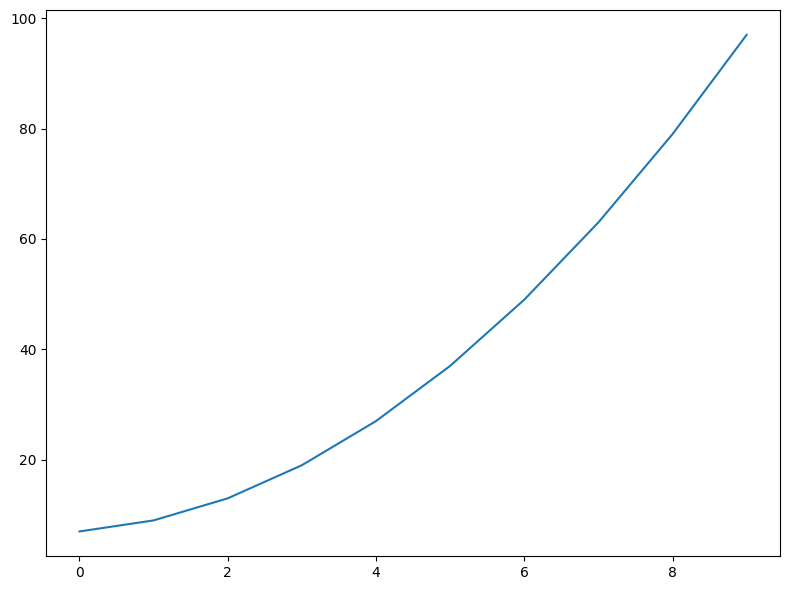

In [275]:
fig, ax = plt.subplots(figsize = (8, 6))

sns.lineplot(pd.Series(y), ax = ax)

plt.tight_layout()
plt.show()

In [265]:
stl = STL(
    pd.Series(y),
    period = 45,
    robust = True
).fit()

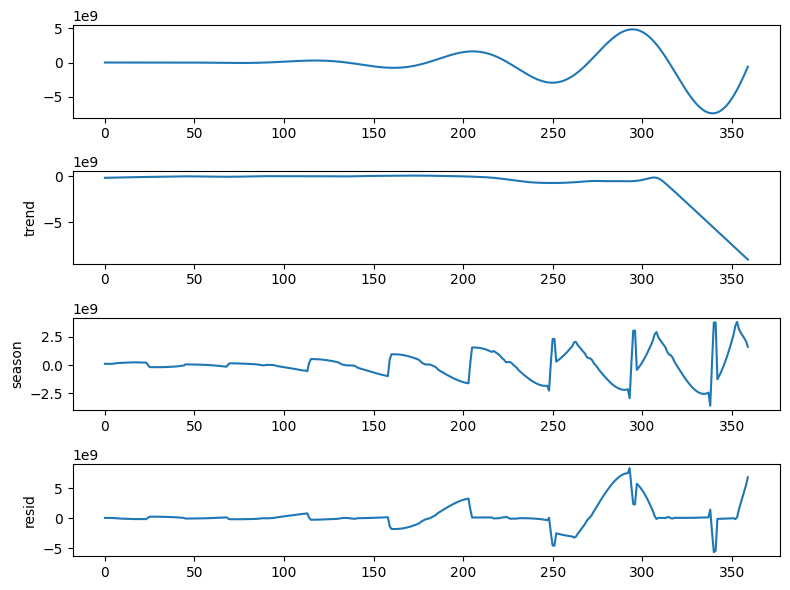

In [266]:
fig, ax = plt.subplots(4, 1, figsize = (8, 6))

sns.lineplot(pd.Series(y), ax = ax[0])
sns.lineplot(stl.trend, ax = ax[1])
sns.lineplot(stl.seasonal, ax = ax[2])
sns.lineplot(stl.resid, ax = ax[3])

plt.tight_layout()
plt.show()

In [264]:
lag_correlation(
    pd.Series(y), nlags = 200, alpha = 0.05
).iloc[30: 80]

,lags,coef,pvalue
30,34,-0.661,0.000
31,35,-0.719,0.000
32,36,-0.773,0.000
33,37,-0.822,0.000
34,38,-0.865,0.000
35,39,-0.902,0.000
36,40,-0.932,0.000
37,41,-0.957,0.000
38,42,-0.976,0.000
39,43,-0.988,0.000


In [197]:
fsin(60)

np.float64(0.8660254037844386)

In [ ]:
np.sin(theta) = 3 / 5

In [185]:
np.sin(0)

np.float64(0.0)

In [153]:
site_usage

,week,consumed_tonnes
0,2021-12-27,45.26
1,2022-01-03,101.04
2,2022-01-10,80.42
3,2022-01-17,0.00
4,2022-01-24,126.46
...,...,...
153,2024-12-02,78.03
154,2024-12-09,61.48
155,2024-12-16,56.80
156,2024-12-23,56.45
